# Group 8 — People Analytics: Who's a Flight Risk?
### Data Understanding, Cleaning & Exploratory Data Analysis

**Dataset:** IBM HR Analytics Employee Attrition
**Goal:** Understand and clean the raw data, then explore what patterns relate to attrition,
before moving on to clustering and predictive modelling.


## 1. Import libraries

In [2]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

os.makedirs("charts", exist_ok=True)
sns.set_style("whitegrid")
%matplotlib inline


## 2. Load raw dataset

In [3]:
df = pd.read_csv("Employee-Attrition.csv")
print(f"Dataset loaded: {df.shape[0]} rows, {df.shape[1]} columns")
df.head()


Dataset loaded: 1470 rows, 35 columns


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


## 3. Data Understanding

We look at the raw data before touching anything, so every cleaning decision
later is based on evidence, not guesswork.

### 3.1 Shape

In [4]:
print(f"Shape: {df.shape[0]} rows, {df.shape[1]} columns")


Shape: 1470 rows, 35 columns


### 3.2 Data types

In [5]:
df.dtypes


Age                         int64
Attrition                     str
BusinessTravel                str
DailyRate                   int64
Department                    str
DistanceFromHome            int64
Education                   int64
EducationField                str
EmployeeCount               int64
EmployeeNumber              int64
EnvironmentSatisfaction     int64
Gender                        str
HourlyRate                  int64
JobInvolvement              int64
JobLevel                    int64
JobRole                       str
JobSatisfaction             int64
MaritalStatus                 str
MonthlyIncome               int64
MonthlyRate                 int64
NumCompaniesWorked          int64
Over18                        str
OverTime                      str
PercentSalaryHike           int64
PerformanceRating           int64
RelationshipSatisfaction    int64
StandardHours               int64
StockOptionLevel            int64
TotalWorkingYears           int64
TrainingTimesL

### 3.3 Unique values

In [6]:
df.nunique().sort_values()


EmployeeCount                  1
Over18                         1
StandardHours                  1
Attrition                      2
OverTime                       2
PerformanceRating              2
Gender                         2
BusinessTravel                 3
Department                     3
MaritalStatus                  3
RelationshipSatisfaction       4
StockOptionLevel               4
JobSatisfaction                4
EnvironmentSatisfaction        4
JobInvolvement                 4
WorkLifeBalance                4
Education                      5
JobLevel                       5
EducationField                 6
TrainingTimesLastYear          7
JobRole                        9
NumCompaniesWorked            10
PercentSalaryHike             15
YearsSinceLastPromotion       16
YearsWithCurrManager          18
YearsInCurrentRole            19
DistanceFromHome              29
YearsAtCompany                37
TotalWorkingYears             40
Age                           43
HourlyRate

### 3.4 Descriptive statistics

In [7]:
df.describe().T


,count,mean,std,min,25%,50%,75%,max
Age,1470.0,36.923810,9.135373,18.0,30.00,36.0,43.00,60.0
DailyRate,1470.0,802.485714,403.509100,102.0,465.00,802.0,1157.00,1499.0
DistanceFromHome,1470.0,9.192517,8.106864,1.0,2.00,7.0,14.00,29.0
Education,1470.0,2.912925,1.024165,1.0,2.00,3.0,4.00,5.0
EmployeeCount,1470.0,1.000000,0.000000,1.0,1.00,1.0,1.00,1.0
EmployeeNumber,1470.0,1024.865306,602.024335,1.0,491.25,1020.5,1555.75,2068.0
EnvironmentSatisfaction,1470.0,2.721769,1.093082,1.0,2.00,3.0,4.00,4.0
HourlyRate,1470.0,65.891156,20.329428,30.0,48.00,66.0,83.75,100.0
JobInvolvement,1470.0,2.729932,0.711561,1.0,2.00,3.0,3.00,4.0
JobLevel,1470.0,2.063946,1.106940,1.0,1.00,2.0,3.00,5.0


## 4. Data Cleaning

Steps: check for missing values, duplicates, constant columns, ID columns,
outliers, then encode text columns into numbers.

### 4.1 Missing values

In [8]:
missing = df.isnull().sum()
missing = missing[missing > 0]
print(f"Columns with missing values: {len(missing)}")
missing


Columns with missing values: 0


Series([], dtype: int64)

### 4.2 Duplicates

In [10]:
n_duplicates = df.duplicated().sum()
print(f"Duplicate rows: {n_duplicates}")
df = df.drop_duplicates()


Duplicate rows: 0


### 4.3 Constant columns

A constant column has the exact same value for every employee, so it carries
zero information for prediction or clustering.

In [11]:
constant_columns = [col for col in df.columns if df[col].nunique() == 1]
print(f"Constant columns (same value everywhere): {constant_columns}")


Constant columns (same value everywhere): ['EmployeeCount', 'Over18', 'StandardHours']


### 4.4 ID columns

`EmployeeNumber` is just a name tag, not a real feature — it gets dropped too.

In [12]:
id_columns = ["EmployeeNumber"] if "EmployeeNumber" in df.columns else []
print(f"ID columns to drop: {id_columns}")

df = df.drop(columns=constant_columns + id_columns)
print(f"Shape after dropping constant/ID columns: {df.shape}")


ID columns to drop: ['EmployeeNumber']
Shape after dropping constant/ID columns: (1470, 31)


### 4.5 Outlier investigation

We use boxplots to visually check every numeric column for extreme values.

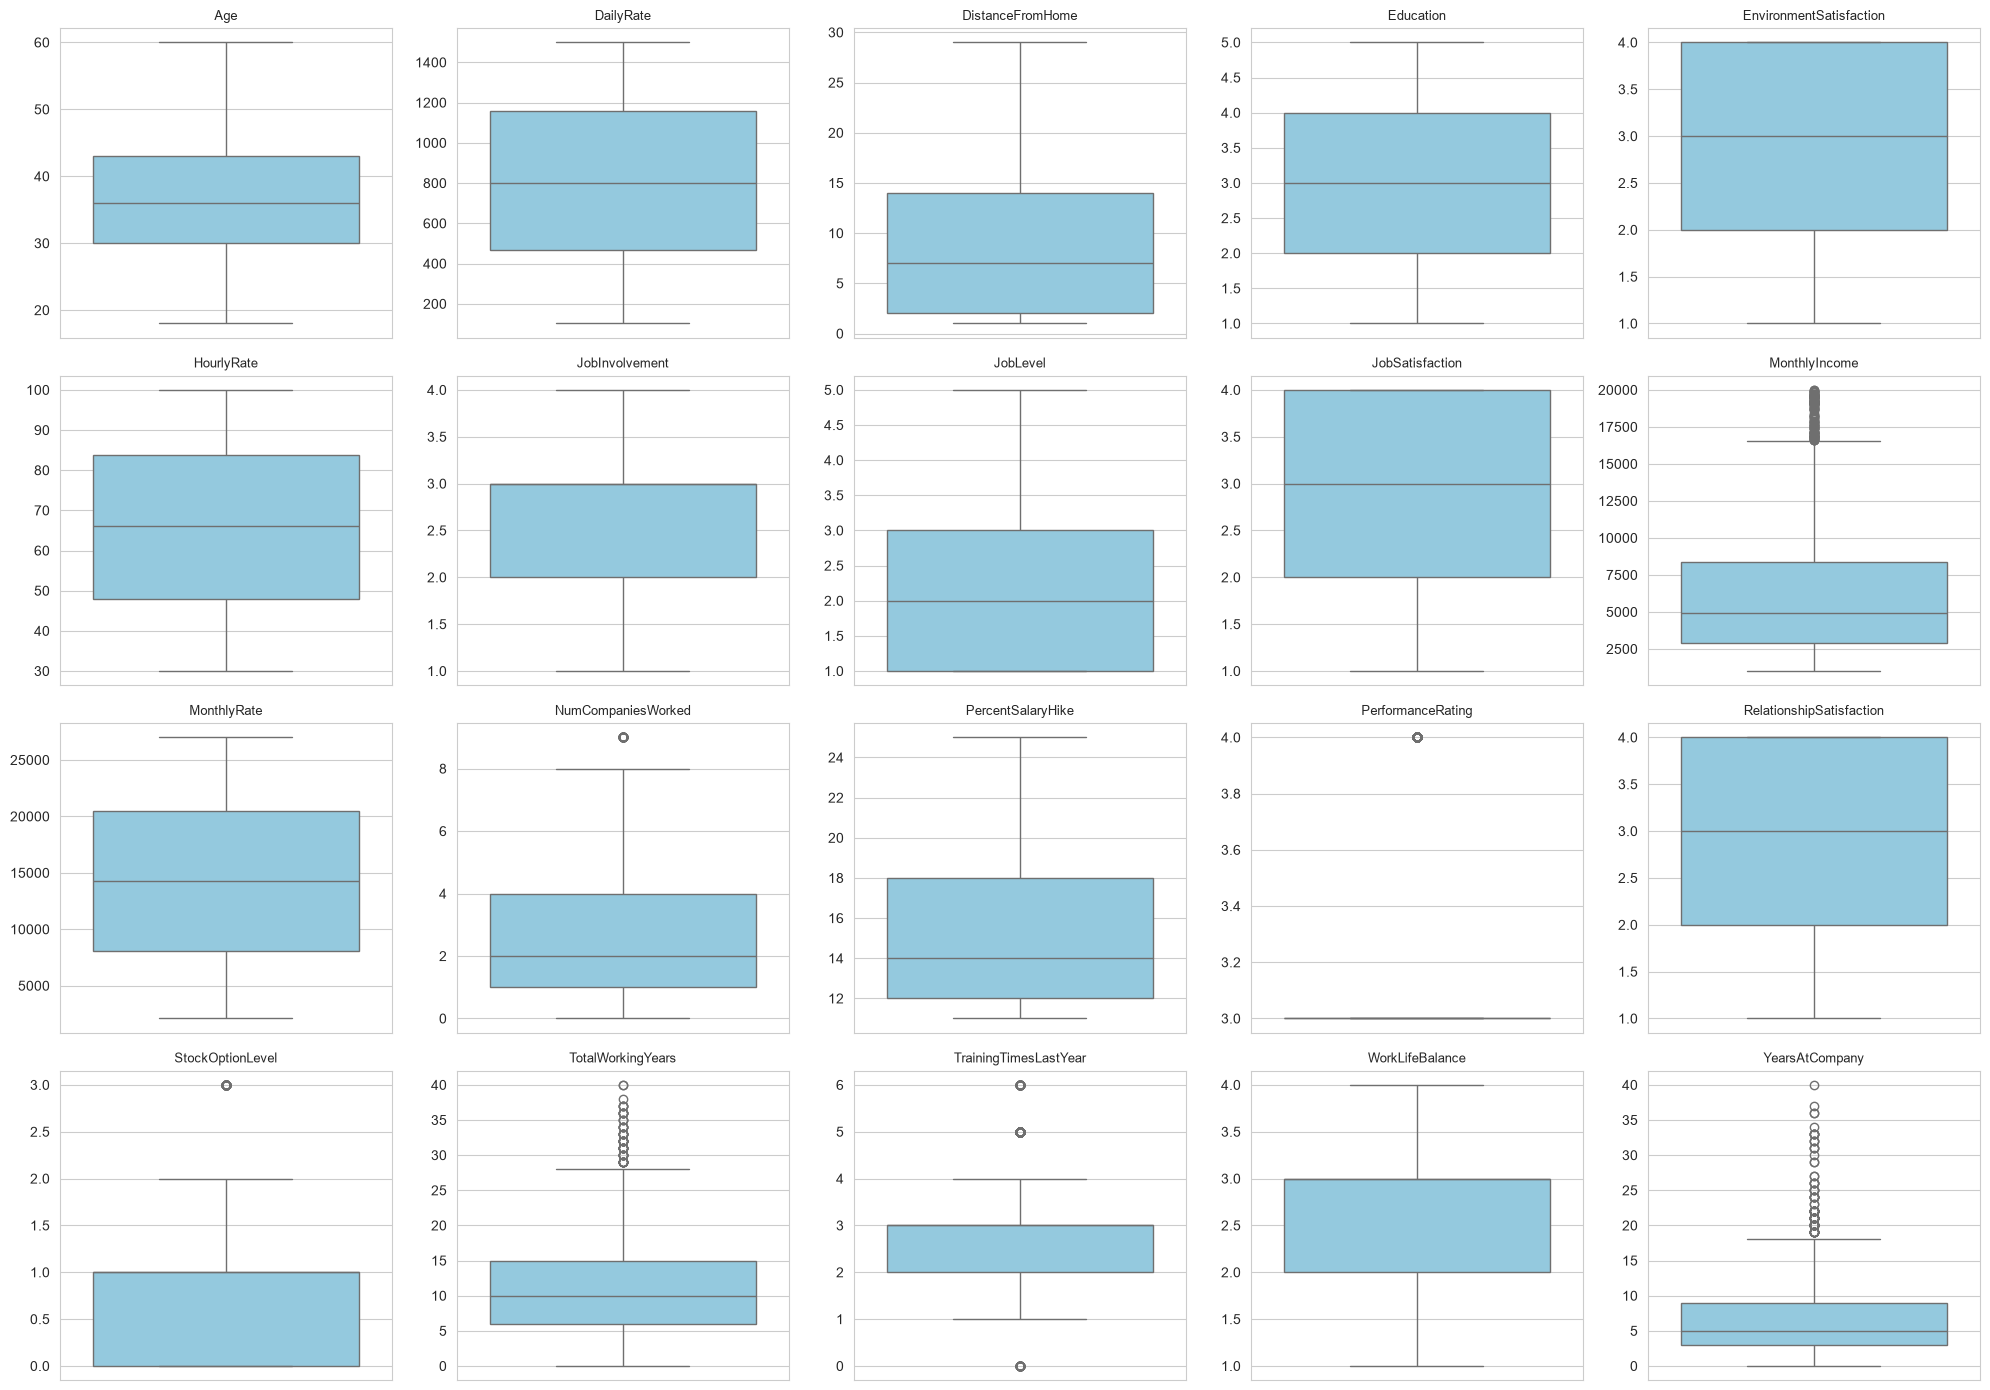

In [13]:
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()

fig, axes = plt.subplots(4, 5, figsize=(20, 14))
axes = axes.flatten()
for i, col in enumerate(numeric_cols[:20]):
    sns.boxplot(y=df[col], ax=axes[i], color="skyblue")
    axes[i].set_title(col, fontsize=9)
    axes[i].set_ylabel("")
for j in range(len(numeric_cols), len(axes)):
    fig.delaxes(axes[j])
plt.tight_layout()
plt.savefig("charts/01_outlier_boxplots.png", dpi=150)
plt.show()


In [14]:
# Quantify potential outliers using the IQR method

outlier_summary = []

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outlier_count = (
        (df[col] < lower_bound) |
        (df[col] > upper_bound)
    ).sum()

    outlier_summary.append({
        "Feature": col,
        "Outlier Count": outlier_count,
        "Outlier %": round(outlier_count / len(df) * 100, 2)
    })

outlier_summary = pd.DataFrame(outlier_summary)

outlier_summary[outlier_summary["Outlier Count"] > 0]

,Feature,Outlier Count,Outlier %
9,MonthlyIncome,114,7.76
11,NumCompaniesWorked,52,3.54
13,PerformanceRating,226,15.37
15,StockOptionLevel,85,5.78
16,TotalWorkingYears,63,4.29
17,TrainingTimesLastYear,238,16.19
19,YearsAtCompany,104,7.07
20,YearsInCurrentRole,21,1.43
21,YearsSinceLastPromotion,107,7.28
22,YearsWithCurrManager,14,0.95


**Outlier Handling Decision**

Potential outliers were identified using boxplots and the IQR method.

The identified observations were retained because extreme values in variables
such as MonthlyIncome, TotalWorkingYears and YearsAtCompany can represent
legitimate employee characteristics, such as senior or highly experienced
employees, rather than data-entry errors.

Therefore, no observations were removed or capped solely because they were
identified as statistical outliers. This preserves the original employee
population and avoids removing potentially meaningful information.

The outliers were therefore handled through detection, investigation and
documented justification rather than automatic removal.

### 4.6 Encoding

In [15]:
# Convert simple Yes/No columns into 1/0
yes_no_columns = ["Attrition", "OverTime"]
for col in yes_no_columns:
    if col in df.columns:
        df[col] = df[col].map({"Yes": 1, "No": 0})

# One-hot encode the remaining multi-category columns
categorical_columns = df.select_dtypes(include="object").columns.tolist()
print(f"Categorical columns encoded: {categorical_columns}")

df_clean = pd.get_dummies(df, columns=categorical_columns, drop_first=True)
print(f"Final cleaned shape: {df_clean.shape}")

df_clean.to_csv("Employee-Attrition-Clean.csv", index=False)
print("Saved Employee-Attrition-Clean.csv")


Categorical columns encoded: ['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus']
Final cleaned shape: (1470, 45)
Saved Employee-Attrition-Clean.csv


C:\Users\Hp\AppData\Local\Temp\ipykernel_22248\2213683589.py:8: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = df.select_dtypes(include="object").columns.tolist()


## 5. Exploratory Data Analysis

For readability, charts use the pre-encoding version of the data (plain text
labels like "Yes"/"No" and department names), while the correlation heatmap
uses the fully encoded numeric version.

In [16]:
df_eda = df.copy()
df_eda["Attrition"] = df_eda["Attrition"].map({1: "Yes", 0: "No"})

### 5.1 Attrition distribution

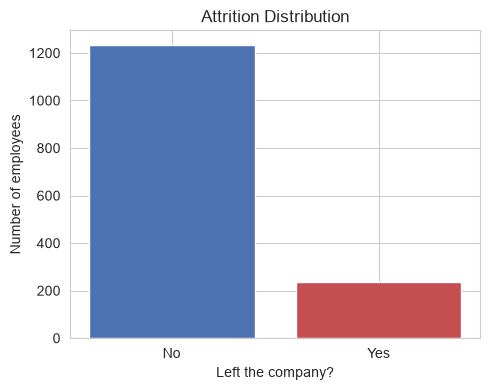

Attrition rate: 16.1%


In [17]:
plt.figure(figsize=(5, 4))
order = ["No", "Yes"]
colors_map = {"No": "#4C72B0", "Yes": "#C44E52"}
counts = df_eda["Attrition"].value_counts().reindex(order)

plt.bar(order, counts.values, color=[colors_map[o] for o in order])
plt.title("Attrition Distribution")
plt.xlabel("Left the company?")
plt.ylabel("Number of employees")
plt.tight_layout()
plt.savefig("charts/02_attrition_distribution.png", dpi=150)
plt.show()
rate = df_eda["Attrition"].value_counts(normalize=True)["Yes"]
print(f"Attrition rate: {rate:.1%}")


**Reading this chart:** the dataset is imbalanced — far fewer employees
left than stayed. This is why accuracy alone would be a misleading metric
later; we'll need F1 / PR-AUC for the supervised models.

### 5.2 Numerical distributions

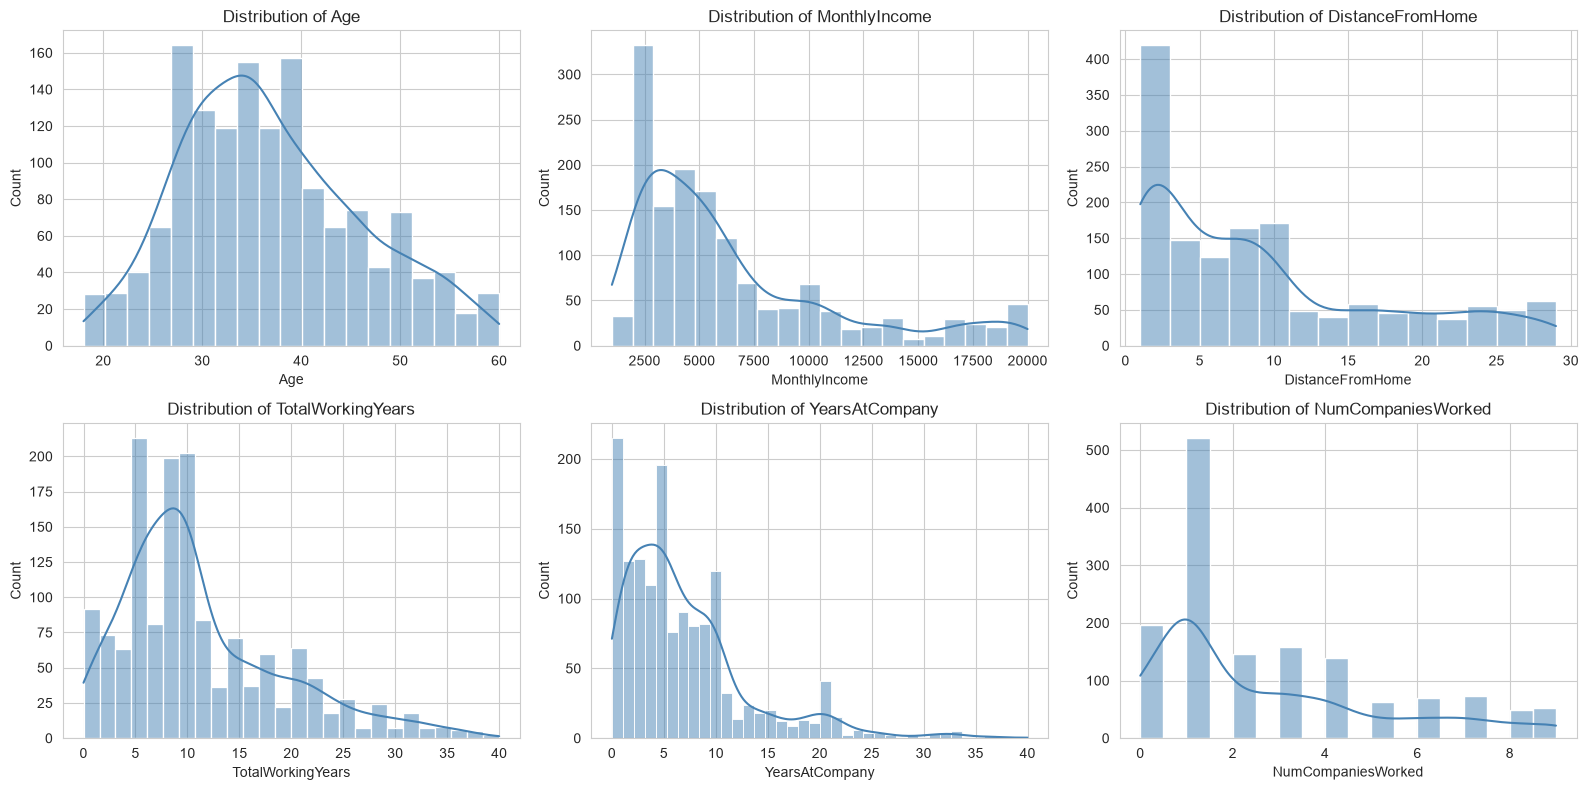

In [18]:
key_numeric = ["Age", "MonthlyIncome", "DistanceFromHome", "TotalWorkingYears",
                "YearsAtCompany", "NumCompaniesWorked"]

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()
for i, col in enumerate(key_numeric):
    sns.histplot(df_eda[col], kde=True, ax=axes[i], color="steelblue")
    axes[i].set_title(f"Distribution of {col}")
plt.tight_layout()
plt.savefig("charts/03_numerical_distributions.png", dpi=150)
plt.show()


### 5.3 Categorical vs Attrition

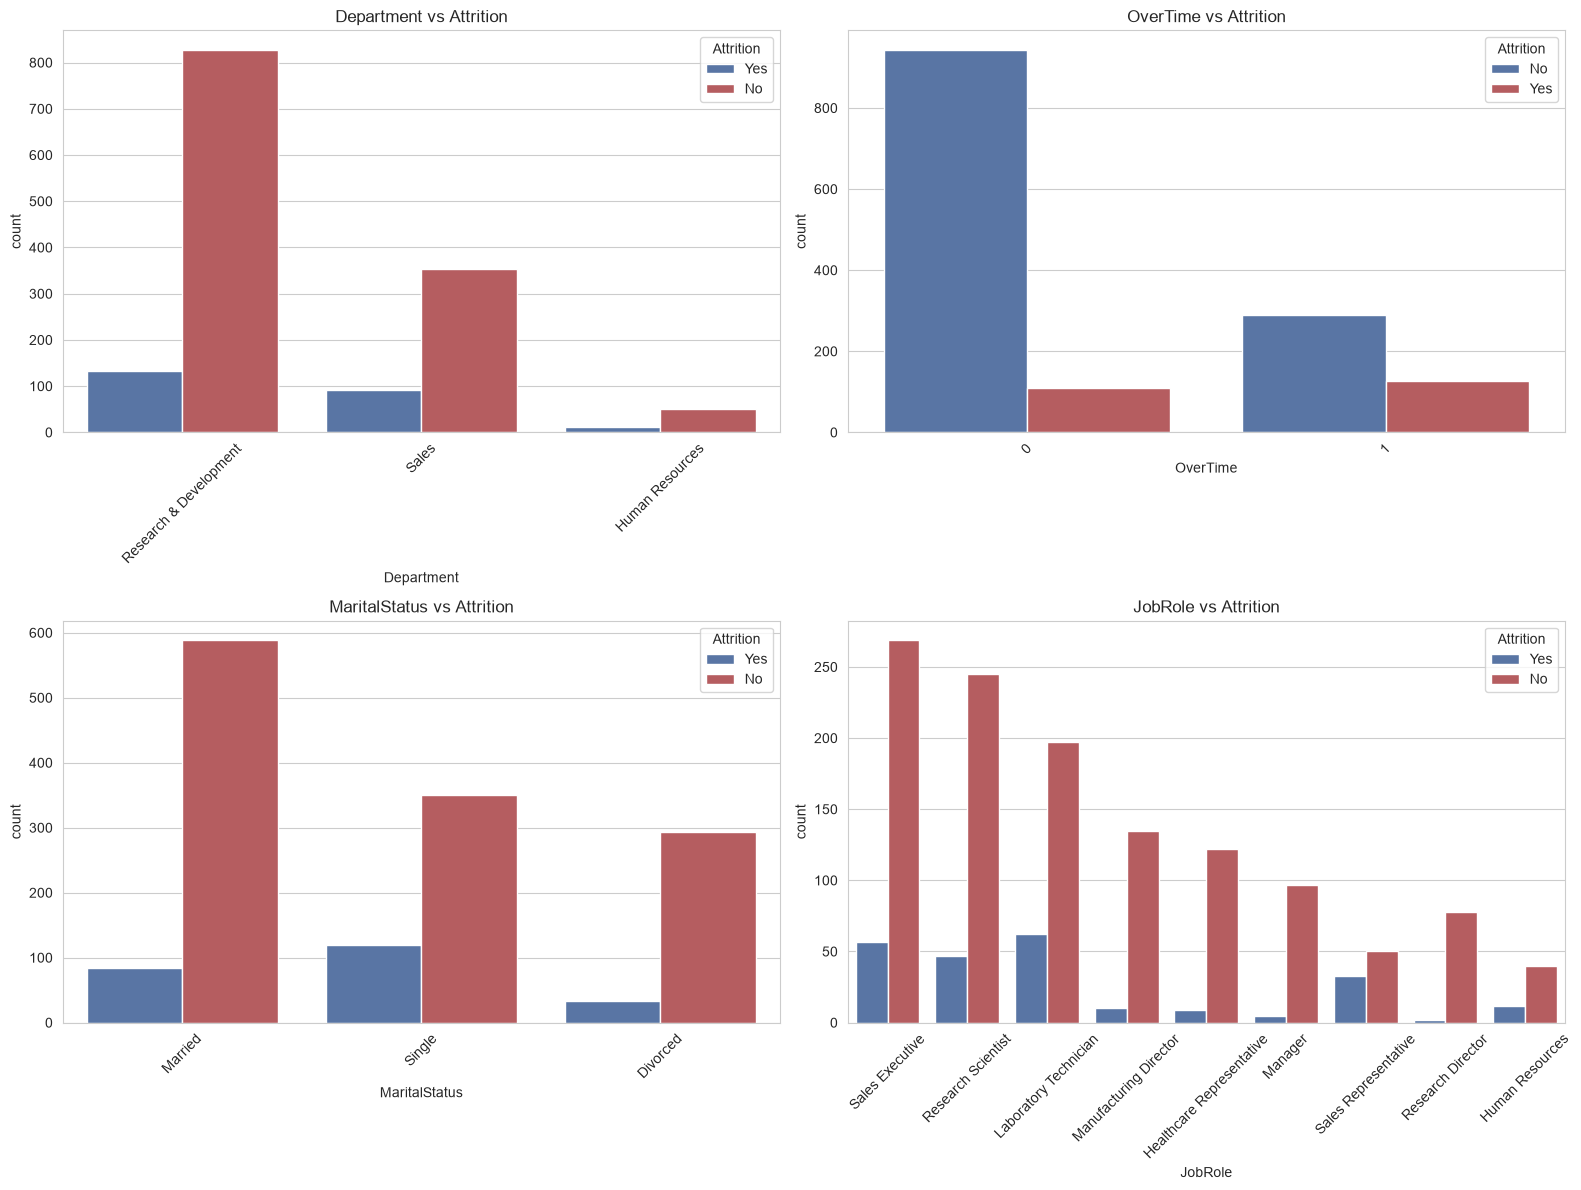

In [19]:
key_categorical = ["Department", "OverTime", "MaritalStatus", "JobRole"]

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()
for i, col in enumerate(key_categorical):
    order = df_eda[col].value_counts().index
    sns.countplot(data=df_eda, x=col, hue="Attrition", ax=axes[i], order=order,
                  palette=["#4C72B0", "#C44E52"])
    axes[i].set_title(f"{col} vs Attrition")
    axes[i].tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.savefig("charts/04_categorical_vs_attrition.png", dpi=150)
plt.show()


**Reading this chart:** watch for categories where the red ("Yes") share
looks noticeably bigger — e.g. employees who work overtime tend to show a
higher share of attrition than those who don't.

### 5.4 Numerical vs Attrition

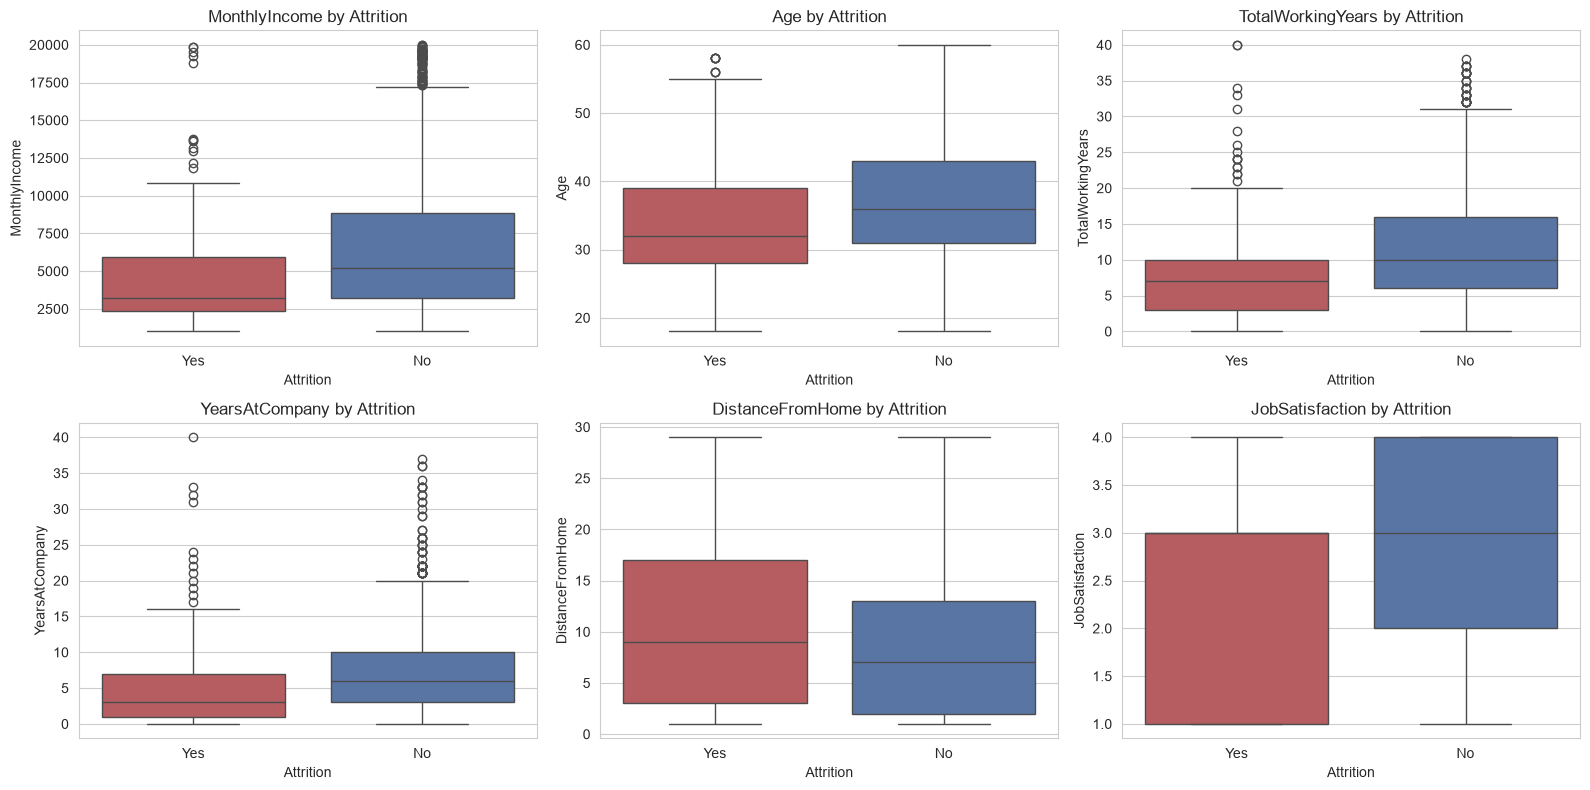

In [20]:
key_numeric_2 = ["MonthlyIncome", "Age", "TotalWorkingYears",
                  "YearsAtCompany", "DistanceFromHome", "JobSatisfaction"]

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()
for i, col in enumerate(key_numeric_2):
    sns.boxplot(data=df_eda, x="Attrition", y=col, hue="Attrition", ax=axes[i],
                palette={"No": "#4C72B0", "Yes": "#C44E52"}, legend=False)
    axes[i].set_title(f"{col} by Attrition")
plt.tight_layout()
plt.savefig("charts/05_numerical_vs_attrition.png", dpi=150)
plt.show()


### 5.5 Correlation analysis

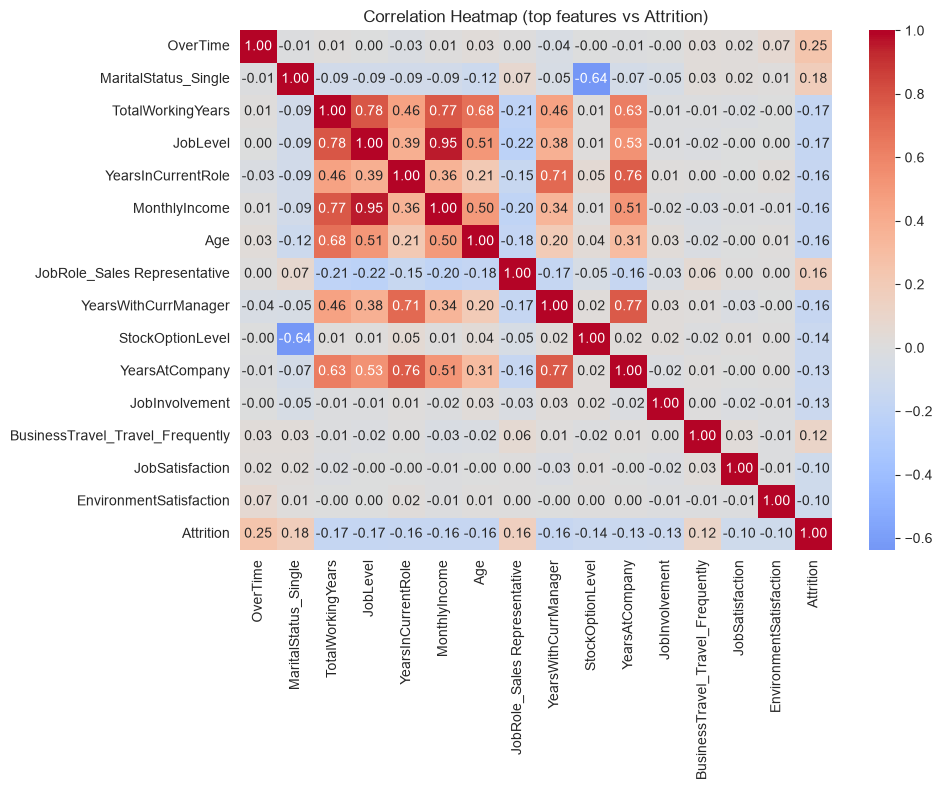

Features most correlated with Attrition:


Attrition                       1.000000
OverTime                        0.246118
MaritalStatus_Single            0.175419
TotalWorkingYears              -0.171063
JobLevel                       -0.169105
YearsInCurrentRole             -0.160545
MonthlyIncome                  -0.159840
Age                            -0.159205
JobRole_Sales Representative    0.157234
YearsWithCurrManager           -0.156199
Name: Attrition, dtype: float64

In [21]:
plt.figure(figsize=(10, 8))
top_corr = df_clean.corr(numeric_only=True)["Attrition"].sort_values(key=abs, ascending=False)
top_features = top_corr.index[1:16]  # skip Attrition itself, take top 15
corr_matrix = df_clean[top_features.tolist() + ["Attrition"]].corr()

sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation Heatmap (top features vs Attrition)")
plt.tight_layout()
plt.savefig("charts/06_correlation_heatmap.png", dpi=150)
plt.show()

print("Features most correlated with Attrition:")
top_corr.head(10)


**Key takeaway:** no single factor strongly drives attrition on its own
(all correlations are below 0.3). `OverTime`, being `Single`, and having fewer
`TotalWorkingYears` / lower `JobLevel` / lower `MonthlyIncome` / younger `Age`
show the clearest — but still modest — links. This matches what we'll likely
see later in clustering: attrition risk is a mix of many small signals rather
than one dominant cause.

## 6. Unsupervised Learning

The goal of the unsupervised analysis is to identify employee personas based
on characteristics related to engagement, satisfaction, workload and tenure.

Attrition is excluded from the clustering features because it is the outcome
we want to examine after creating the employee groups. This prevents the
clustering process from using the target variable to define the personas.

### 6.1 Feature Selection

The following variables were selected to represent four relevant aspects of
the employee experience:

- Engagement: JobInvolvement
- Satisfaction: JobSatisfaction, EnvironmentSatisfaction,
  RelationshipSatisfaction and WorkLifeBalance
- Workload: OverTime
- Tenure: TotalWorkingYears, YearsAtCompany, YearsInCurrentRole,
  YearsSinceLastPromotion and YearsWithCurrManager

These features are used to create employee personas without directly using
Attrition.

In [22]:
# Features selected for employee persona clustering

cluster_features = [
    "JobInvolvement",
    "JobSatisfaction",
    "EnvironmentSatisfaction",
    "RelationshipSatisfaction",
    "WorkLifeBalance",
    "OverTime",
    "TotalWorkingYears",
    "YearsAtCompany",
    "YearsInCurrentRole",
    "YearsSinceLastPromotion",
    "YearsWithCurrManager"
]

cluster_df = df_eda[cluster_features].copy()

print("Clustering data shape:", cluster_df.shape)
cluster_df.head()

Clustering data shape: (1470, 11)


,JobInvolvement,JobSatisfaction,EnvironmentSatisfaction,RelationshipSatisfaction,WorkLifeBalance,OverTime,TotalWorkingYears,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,3,4,2,1,1,1,8,6,4,0,5
1,2,2,3,4,3,0,10,10,7,1,7
2,2,3,4,2,3,1,7,0,0,0,0
3,3,3,4,3,3,1,8,8,7,3,0
4,3,2,1,4,3,0,6,2,2,2,2


### 6.2 Feature Scaling

The selected variables have different numerical ranges. For example,
tenure variables are measured in years, satisfaction variables use rating
scales, and OverTime is binary.

StandardScaler is therefore used so that each feature contributes on a
comparable scale. This is particularly important for PCA and K-Means because
both rely on the geometry of the feature space.

In [23]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_cluster_scaled = scaler.fit_transform(cluster_df)

print("Scaled data shape:", X_cluster_scaled.shape)

Scaled data shape: (1470, 11)


## 6.3 Principal Component Analysis (PCA)

PCA is applied to the standardized clustering features to reduce
dimensionality and identify the main dimensions of variation among
employees.

The explained variance ratio is examined to determine how much of the
total variation is captured by each principal component. The cumulative
explained variance is then used to justify the number of components
retained.

In [24]:
from sklearn.decomposition import PCA

# Fit PCA using all available components
pca_full = PCA()

X_pca_full = pca_full.fit_transform(X_cluster_scaled)

explained_variance = pca_full.explained_variance_ratio_
cumulative_variance = explained_variance.cumsum()

pca_summary = pd.DataFrame({
    "Component": range(1, len(explained_variance) + 1),
    "Explained Variance": explained_variance,
    "Cumulative Variance": cumulative_variance
})

pca_summary.round(4)

,Component,Explained Variance,Cumulative Variance
0,1,0.3073,0.3073
1,2,0.0994,0.4067
2,3,0.0952,0.5019
3,4,0.0939,0.5958
4,5,0.0892,0.6850
5,6,0.0874,0.7724
6,7,0.0815,0.8539
7,8,0.0564,0.9104
8,9,0.0481,0.9585
9,10,0.0256,0.9841


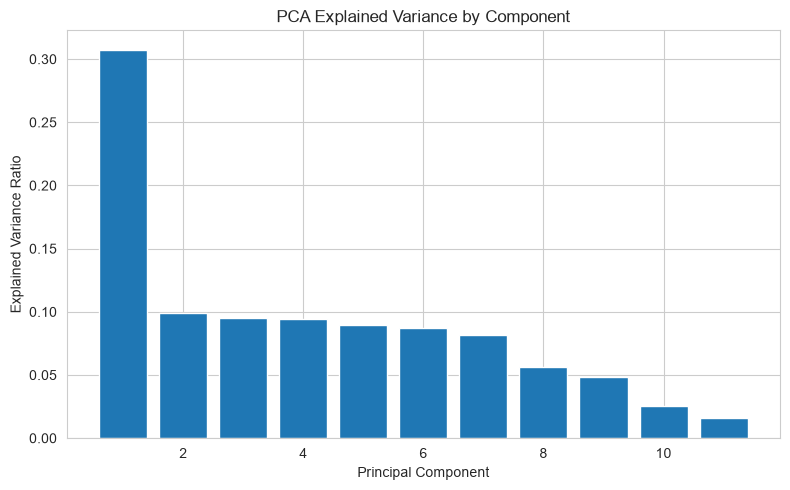

In [25]:
plt.figure(figsize=(8, 5))

plt.bar(
    range(1, len(explained_variance) + 1),
    explained_variance
)

plt.xlabel("Principal Component")
plt.ylabel("Explained Variance Ratio")
plt.title("PCA Explained Variance by Component")

plt.tight_layout()
plt.show()

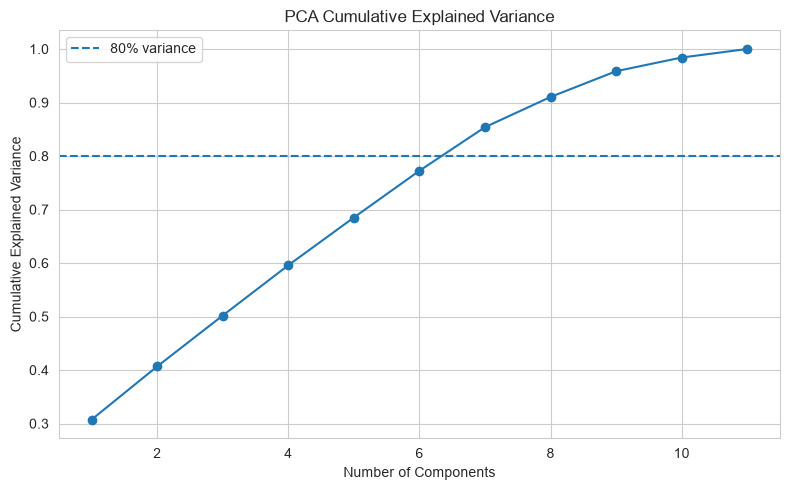

In [26]:
plt.figure(figsize=(8, 5))

plt.plot(
    range(1, len(cumulative_variance) + 1),
    cumulative_variance,
    marker="o"
)

plt.axhline(
    0.80,
    linestyle="--",
    label="80% variance"
)

plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA Cumulative Explained Variance")

plt.legend()
plt.tight_layout()
plt.show()

In [27]:
n_components_80 = np.argmax(
    cumulative_variance >= 0.80
) + 1

print(
    f"Components needed for at least 80% variance: "
    f"{n_components_80}"
)

print(
    f"Variance explained: "
    f"{cumulative_variance[n_components_80 - 1]:.2%}"
)

Components needed for at least 80% variance: 7
Variance explained: 85.39%


In [28]:
# PCA loadings for the first two principal components

pca_2 = PCA(n_components=2)

X_pca_2 = pca_2.fit_transform(X_cluster_scaled)

loadings = pd.DataFrame(
    pca_2.components_.T,
    columns=["PC1", "PC2"],
    index=cluster_features
)

loadings.round(3)

,PC1,PC2
JobInvolvement,-0.003,0.044
JobSatisfaction,-0.013,0.060
EnvironmentSatisfaction,0.005,0.560
RelationshipSatisfaction,0.010,0.449
WorkLifeBalance,0.015,0.033
OverTime,-0.016,0.688
TotalWorkingYears,0.382,0.047
YearsAtCompany,0.505,0.007
YearsInCurrentRole,0.468,-0.021
YearsSinceLastPromotion,0.404,0.033


In [29]:
print("Strongest contributors to PC1:")
print(
    loadings["PC1"]
    .abs()
    .sort_values(ascending=False)
    .head(5)
)

print("\nStrongest contributors to PC2:")
print(
    loadings["PC2"]
    .abs()
    .sort_values(ascending=False)
    .head(5)
)

Strongest contributors to PC1:
YearsAtCompany             0.505290
YearsInCurrentRole         0.467851
YearsWithCurrManager       0.464415
YearsSinceLastPromotion    0.403979
TotalWorkingYears          0.382238
Name: PC1, dtype: float64

Strongest contributors to PC2:
OverTime                    0.687917
EnvironmentSatisfaction     0.559676
RelationshipSatisfaction    0.448637
JobSatisfaction             0.060341
TotalWorkingYears           0.046648
Name: PC2, dtype: float64


### PCA Component Interpretation

The PCA loadings show that the first two principal components capture
different aspects of employee characteristics.

**PC1 — Tenure and Organizational Experience**

PC1 is dominated by YearsAtCompany (0.505), YearsInCurrentRole (0.468),
YearsWithCurrManager (0.464), YearsSinceLastPromotion (0.404), and
TotalWorkingYears (0.382). Therefore, PC1 can be interpreted as a
tenure and organizational experience dimension. Higher PC1 values are
associated mainly with employees who have longer organizational and
professional experience.

**PC2 — Workload and Workplace Satisfaction**

PC2 is dominated by OverTime (0.688), EnvironmentSatisfaction (0.560), and
RelationshipSatisfaction (0.449). Therefore, PC2 is primarily associated with
workload and workplace satisfaction based on the largest absolute loadings,
with OverTime being the strongest contributor.

The signs of PCA loadings indicate the direction of the relationship, but
the overall sign of a principal component is arbitrary. Therefore, the
interpretation focuses mainly on the magnitude and relative contribution
of the loadings.

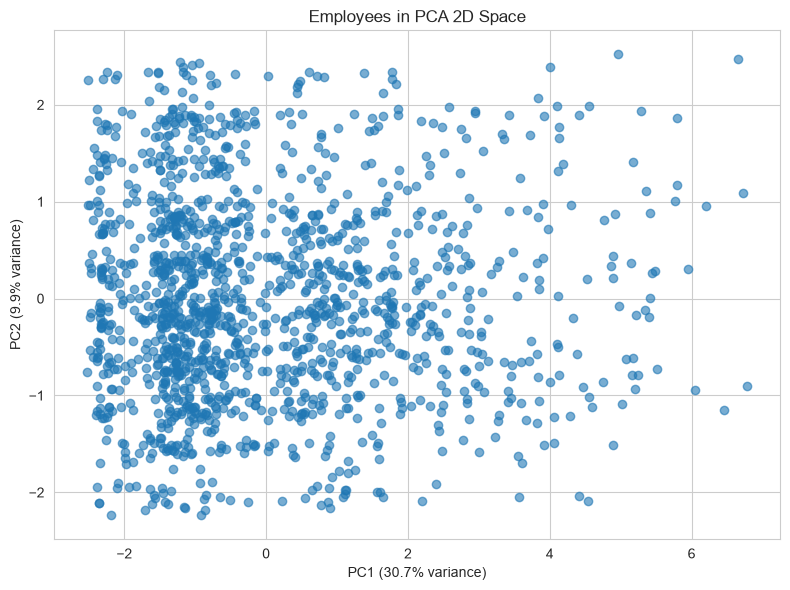

In [30]:
plt.figure(figsize=(8, 6))

plt.scatter(
    X_pca_2[:, 0],
    X_pca_2[:, 1],
    alpha=0.6
)

plt.xlabel(
    f"PC1 ({pca_2.explained_variance_ratio_[0] * 100:.1f}% variance)"
)

plt.ylabel(
    f"PC2 ({pca_2.explained_variance_ratio_[1] * 100:.1f}% variance)"
)

plt.title("Employees in PCA 2D Space")

plt.tight_layout()
plt.show()

## 6.4 K-Means Clustering

K-Means clustering is used to group employees into personas based on their
engagement, satisfaction, workload and tenure characteristics.

The clustering is performed on the standardized features so that variables
with larger numerical ranges do not dominate the distance calculations.

Different values of K are evaluated using the elbow method and silhouette
score before selecting the final number of clusters.

In [31]:
#Testing different values of K
import os
import warnings
warnings.filterwarnings("ignore")
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

K_range = range(2, 9)

inertias = []
silhouette_scores = []

for k in K_range:
    kmeans = KMeans(
        n_clusters=k,
        init="k-means++",
        n_init=10,
        random_state=42
    )
    
    labels = kmeans.fit_predict(X_cluster_scaled)
    
    inertias.append(kmeans.inertia_)
    silhouette_scores.append(
        silhouette_score(X_cluster_scaled, labels)
    )

print("K values tested:", list(K_range))

K values tested: [2, 3, 4, 5, 6, 7, 8]


In [32]:
cluster_evaluation = pd.DataFrame({
    "K": list(K_range),
    "WCSS / Inertia": inertias,
    "Silhouette Score": silhouette_scores
})

cluster_evaluation.round(4)

,K,WCSS / Inertia,Silhouette Score
0,2,12683.3957,0.2176
1,3,11613.1774,0.1444
2,4,10792.2576,0.1404
3,5,10246.4619,0.1117
4,6,9844.5226,0.1133
5,7,9560.2428,0.1134
6,8,9202.2145,0.1059


### Elbow Method

The elbow method evaluates the within-cluster sum of squares (WCSS), also
reported as K-Means inertia. As the number of clusters increases, WCSS
decreases because observations are assigned to more groups.

The preferred K is around the point where adding additional clusters gives
substantially smaller improvements.

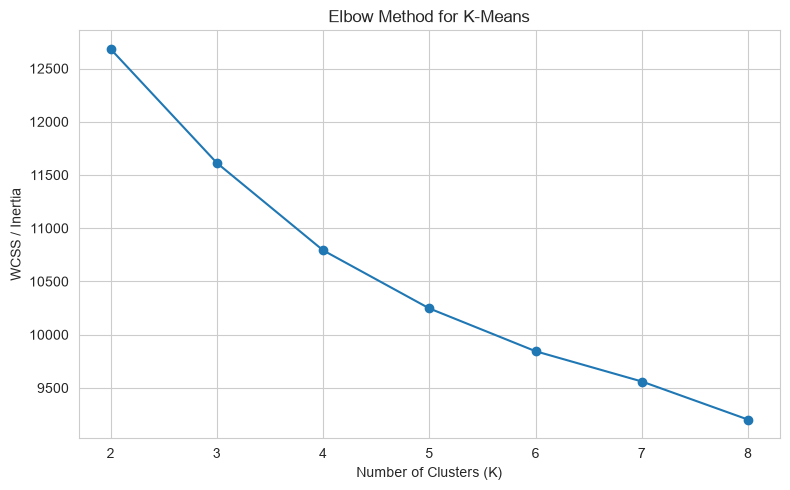

In [33]:
plt.figure(figsize=(8, 5))

plt.plot(
    list(K_range),
    inertias,
    marker="o"
)

plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS / Inertia")
plt.title("Elbow Method for K-Means")

plt.xticks(list(K_range))

plt.tight_layout()
plt.show()

### Silhouette Score

The silhouette score measures how well observations fit within their own
cluster compared with other clusters. Higher values indicate better-defined
and more separated clusters.

The silhouette score is therefore used together with the elbow method rather
than relying on WCSS alone.

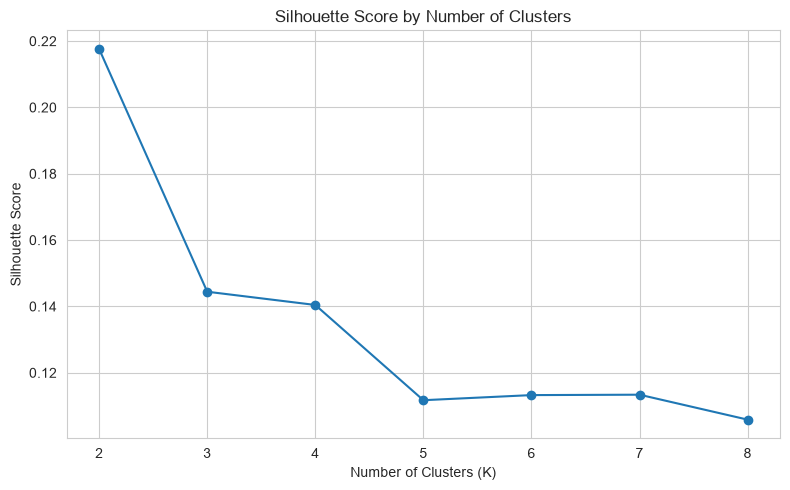

In [34]:
plt.figure(figsize=(8, 5))

plt.plot(
    list(K_range),
    silhouette_scores,
    marker="o"
)

plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score by Number of Clusters")

plt.xticks(list(K_range))

plt.tight_layout()
plt.show()

In [35]:
#Find the Best Silhouette K
best_k_silhouette = list(K_range)[
    np.argmax(silhouette_scores)
]

best_silhouette = max(silhouette_scores)

print(
    f"Best K according to silhouette score: "
    f"{best_k_silhouette}"
)

print(
    f"Best silhouette score: "
    f"{best_silhouette:.4f}"
)

Best K according to silhouette score: 2
Best silhouette score: 0.2176


In [36]:
for k in [2, 3]:
    
    kmeans = KMeans(
        n_clusters=k,
        init="k-means++",
        n_init=10,
        random_state=42
    )
    
    labels = kmeans.fit_predict(X_cluster_scaled)
    
    print(f"\nK = {k}")
    print("Cluster sizes:")
    print(pd.Series(labels).value_counts().sort_index())
    
    print(
        "Silhouette score:",
        round(silhouette_score(X_cluster_scaled, labels), 4)
    )


K = 2
Cluster sizes:
0    957
1    513
Name: count, dtype: int64
Silhouette score: 0.2176

K = 3
Cluster sizes:
0    734
1    414
2    322
Name: count, dtype: int64
Silhouette score: 0.1444


### Selecting the Number of Clusters

The number of clusters was evaluated using both WCSS (inertia) and the
silhouette score.

The silhouette score was highest for K=2, with a score of 0.2176. The score
decreased when additional clusters were introduced. Therefore, K=2 provides
the strongest separation among the tested solutions.

Although the silhouette score is relatively low, indicating that the
clusters are not strongly separated, K=2 is selected because it provides
the best-supported solution according to the clustering evaluation.

The final K-Means model therefore uses two employee clusters.

In [37]:
# Final K-Means model

final_k = 2

kmeans_final = KMeans(
    n_clusters=final_k,
    init="k-means++",
    n_init=10,
    random_state=42
)

cluster_labels = kmeans_final.fit_predict(X_cluster_scaled)

df_clusters = df_eda.copy()

df_clusters["Cluster"] = cluster_labels

print("Final number of clusters:", final_k)
print("\nCluster sizes:")
print(
    df_clusters["Cluster"]
    .value_counts()
    .sort_index()
)

Final number of clusters: 2

Cluster sizes:
Cluster
0    957
1    513
Name: count, dtype: int64


In [38]:
cluster_profile = (
    df_clusters
    .groupby("Cluster")[cluster_features]
    .mean()
    .round(2)
)

cluster_profile

,JobInvolvement,JobSatisfaction,EnvironmentSatisfaction,RelationshipSatisfaction,WorkLifeBalance,OverTime,TotalWorkingYears,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
Cluster,,,,,,,,,,,
0,2.72,2.73,2.71,2.72,2.75,0.30,8.56,3.73,2.15,0.75,2.07
1,2.75,2.73,2.74,2.70,2.78,0.25,16.35,13.13,8.10,4.88,7.96


In [39]:
cluster_sizes = (
    df_clusters["Cluster"]
    .value_counts()
    .sort_index()
)

cluster_summary = pd.DataFrame({
    "Employees": cluster_sizes,
    "Percentage": (
        cluster_sizes / len(df_clusters) * 100
    ).round(2)
})

cluster_summary

,Employees,Percentage
Cluster,,
0,957,65.1
1,513,34.9


In [40]:
cluster_attrition = pd.crosstab(
    df_clusters["Cluster"],
    df_clusters["Attrition"],
    normalize="index"
) * 100

cluster_attrition.round(2)

Attrition,No,Yes
Cluster,,
0,81.19,18.81
1,88.89,11.11


### Cluster Profile Interpretation

The K-Means results identify two distinct employee personas. The main
difference between the clusters is tenure and professional experience,
rather than satisfaction.

**Cluster 0 — Early-Tenure Employees**

Cluster 0 contains 957 employees. This group has substantially lower
organizational and professional tenure, with average TotalWorkingYears of
8.56 years and YearsAtCompany of 3.73 years. Employees in this group also
show slightly higher overtime participation (0.30).

The observed attrition rate for this cluster is 18.81%.

**Cluster 1 — Experienced Long-Tenure Employees**

Cluster 1 contains 513 employees. This group is characterized by much
greater professional and organizational experience, with average
TotalWorkingYears of 16.35 years and YearsAtCompany of 13.13 years.
Employees also have substantially longer tenure in their current role and
with their current manager.

The observed attrition rate for this cluster is 11.11%.

Overall, the clustering solution suggests that tenure and experience are
the strongest characteristics distinguishing the two employee personas,
while the satisfaction and engagement measures are relatively similar
between the clusters.

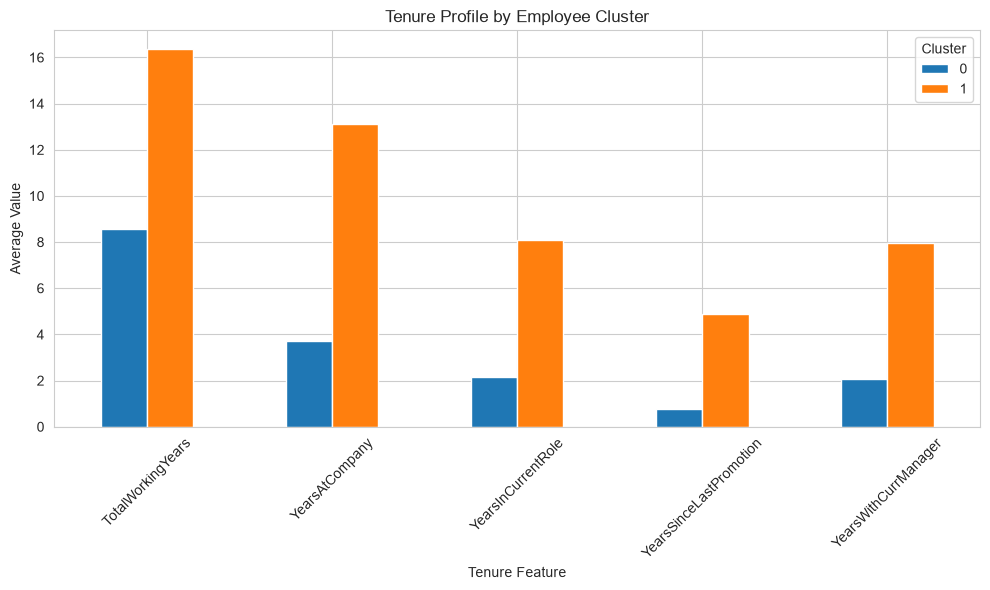

In [41]:
# Compare key tenure characteristics across clusters

profile_plot = cluster_profile[
    [
        "TotalWorkingYears",
        "YearsAtCompany",
        "YearsInCurrentRole",
        "YearsSinceLastPromotion",
        "YearsWithCurrManager"
    ]
]

profile_plot.T.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Tenure Profile by Employee Cluster")
plt.xlabel("Tenure Feature")
plt.ylabel("Average Value")
plt.xticks(rotation=45)
plt.legend(title="Cluster")

plt.tight_layout()
plt.show()

### Cluster and Attrition Relationship

The observed attrition rate is higher in Cluster 0 (18.81%) than in
Cluster 1 (11.11%). This indicates that the early-tenure employee persona
has a higher observed attrition level in this dataset.

However, clustering is descriptive and does not establish that shorter
tenure or overtime causes attrition. The relationship should therefore be
examined further using the supervised learning models.

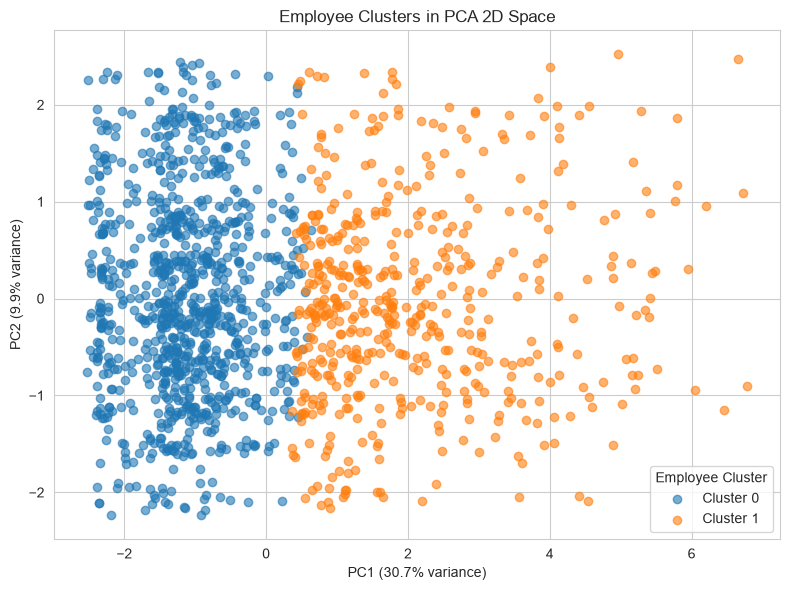

In [42]:
# Visualize the final K-Means clusters using the first two PCA components

plt.figure(figsize=(8, 6))

for cluster in sorted(df_clusters["Cluster"].unique()):
    
    subset = X_pca_2[
        df_clusters["Cluster"].values == cluster
    ]
    
    plt.scatter(
        subset[:, 0],
        subset[:, 1],
        label=f"Cluster {cluster}",
        alpha=0.6
    )

plt.xlabel(
    f"PC1 ({pca_2.explained_variance_ratio_[0] * 100:.1f}% variance)"
)

plt.ylabel(
    f"PC2 ({pca_2.explained_variance_ratio_[1] * 100:.1f}% variance)"
)

plt.title("Employee Clusters in PCA 2D Space")
plt.legend(title="Employee Cluster")

plt.tight_layout()
plt.show()

In [43]:
cluster_final_summary = pd.DataFrame({
    "Employees": cluster_sizes,
    "Percentage": (
        cluster_sizes / len(df_clusters) * 100
    ).round(2),
    "Attrition Rate": (
        df_clusters
        .groupby("Cluster")["Attrition"]
        .apply(lambda x: (x == "Yes").mean() * 100)
        .round(2)
    )
})

cluster_final_summary

,Employees,Percentage,Attrition Rate
Cluster,,,
0,957,65.1,18.81
1,513,34.9,11.11


## 6.5 Unsupervised Learning Conclusion

The unsupervised analysis followed a structured process of feature selection,
standardization, PCA and K-Means clustering.

Eleven features representing employee engagement, satisfaction, workload and
tenure were selected for clustering. The features were standardized using
StandardScaler to ensure that variables with different numerical scales did
not disproportionately influence PCA or K-Means.

PCA showed that the first seven components explain 85.39% of the total
variance. The first two components explain 40.67% and were therefore used for
two-dimensional visualization and component interpretation.

K-Means solutions from K=2 to K=8 were evaluated using WCSS/inertia and
silhouette scores. K=2 produced the highest silhouette score of 0.2176 and
was selected as the final clustering solution. The relatively low silhouette
score indicates that the two groups are not strongly separated, so the
personas should be interpreted as broad employee segments rather than
completely distinct groups.

The final solution identified two employee personas: an early-tenure group
and an experienced long-tenure group. The early-tenure group had an observed
attrition rate of 18.81%, compared with 11.11% for the experienced
long-tenure group.

These personas provide a useful descriptive view of the employee population
and identify differences in observed attrition patterns. The findings will
be complemented by supervised learning to determine which employee
characteristics are most useful for predicting individual attrition risk.

## 7. Supervised Learning: Employee Attrition Prediction

The previous sections of this project focused on data cleaning, exploratory data analysis, and unsupervised learning. In the unsupervised learning stage, K-Means clustering was used to identify employee personas based on similarities in their characteristics. The clustering analysis identified two employee groups with different levels of professional and organisational tenure.

The next stage applies **supervised machine learning** to the employee attrition problem. Unlike unsupervised learning, supervised learning uses a known target variable to learn the relationship between employee characteristics and an outcome.

The objective of this stage is to develop classification models that can predict whether an employee is likely to leave the organisation.

The target variable is **Attrition**, which has two possible outcomes:

* **No** — the employee remains with the organisation.
* **Yes** — the employee leaves the organisation.

This makes the problem a **binary classification task**.

The supervised learning analysis will compare multiple classification algorithms, evaluate their performance using metrics appropriate for an imbalanced dataset, and identify the model that provides the most useful predictions for the HR flight-risk problem.


## 7.1 Target Variable

The target variable for the supervised learning task is **Attrition**.

`Attrition` indicates whether an employee left the organisation:

* `No` = the employee did not leave.
* `Yes` = the employee left.

Because there are only two possible classes, the prediction problem is treated as binary classification.

For machine learning, the target will be encoded numerically:

* `No` → 0
* `Yes` → 1

Encoding the target in this way allows classification algorithms to work with the outcome variable while maintaining the original meaning of the data.


In [44]:
# Check the distribution of the target variable
df["Attrition"].value_counts()

Attrition
0    1233
1     237
Name: count, dtype: int64

In [45]:
# Display the percentage distribution
df["Attrition"].value_counts(normalize=True).mul(100).round(2)

Attrition
0    83.88
1    16.12
Name: proportion, dtype: float64

## 7.2 Class Imbalance

The distribution of the `Attrition` target variable shows that employees who remain with the organisation substantially outnumber employees who leave.

This creates a **class imbalance** problem. The minority class, `Yes`, represents employees who actually left the organisation, while `No` represents employees who remained.

Class imbalance is important because a model could achieve a relatively high accuracy simply by predicting the majority class for most or all employees. Such a model would not be useful for the HR objective because its ability to identify employees who are actually at risk of leaving would be poor.

Therefore, accuracy alone will not be used to select the final model. The supervised learning stage will focus particularly on **precision, recall, F1-score and Precision-Recall Area Under the Curve (PR-AUC)**. These metrics provide more useful information about the model's ability to identify the minority attrition class.

To address the imbalance during model training, class-weighting strategies will be considered where appropriate. This allows the models to give greater importance to observations from the minority class without artificially changing the original observations.


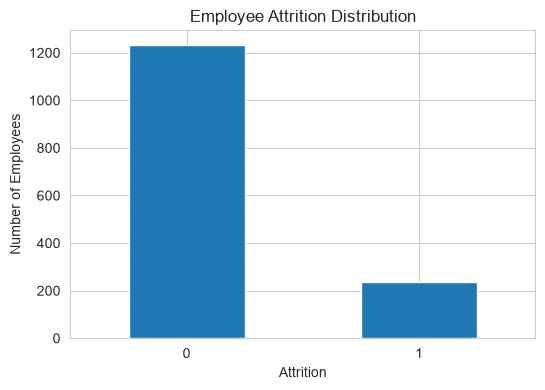

In [46]:
import matplotlib.pyplot as plt

attrition_counts = df["Attrition"].value_counts()

plt.figure(figsize=(6, 4))
attrition_counts.plot(kind="bar")
plt.title("Employee Attrition Distribution")
plt.xlabel("Attrition")
plt.ylabel("Number of Employees")
plt.xticks(rotation=0)
plt.show()

## 7.3 Separation of Features and Target

For supervised learning, the dataset is divided into two components:

* **Features (`X`)** — the employee characteristics used by the model to make predictions.
* **Target (`y`)** — the outcome that the model is trying to predict.

In this project, `Attrition` is the target variable. All remaining relevant employee characteristics form the predictor variables.

The target variable is removed from `X` to ensure that the model does not receive the answer as one of its inputs.


In [47]:
X = df.drop("Attrition", axis=1)
y = df["Attrition"]

print("Original Attrition values:")
print(df["Attrition"].value_counts(dropna=False))

print("\nUnique Attrition values:")
print(df["Attrition"].unique())

print("\nMissing values in y:")
print(y.isna().sum())

Original Attrition values:
Attrition
0    1233
1     237
Name: count, dtype: int64

Unique Attrition values:
[1 0]

Missing values in y:
0


In [48]:
print(df[df["Attrition"].isna()])

Empty DataFrame
Columns: [Age, Attrition, BusinessTravel, DailyRate, Department, DistanceFromHome, Education, EducationField, EnvironmentSatisfaction, Gender, HourlyRate, JobInvolvement, JobLevel, JobRole, JobSatisfaction, MaritalStatus, MonthlyIncome, MonthlyRate, NumCompaniesWorked, OverTime, PercentSalaryHike, PerformanceRating, RelationshipSatisfaction, StockOptionLevel, TotalWorkingYears, TrainingTimesLastYear, WorkLifeBalance, YearsAtCompany, YearsInCurrentRole, YearsSinceLastPromotion, YearsWithCurrManager]
Index: []

[0 rows x 31 columns]


In [49]:

# Attrition was already encoded as 0 = No and 1 = Yes during data cleaning
y = df["Attrition"].copy()

# Create the feature matrix
X = df.drop(columns=["Attrition"])

# Check the dimensions
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (1470, 30)
y shape: (1470,)


In [50]:
print("Target values:")
print(y.value_counts())

Target values:
Attrition
0    1233
1     237
Name: count, dtype: int64


In [51]:
print("Feature columns:")
print(X.columns.tolist())

Feature columns:
['Age', 'BusinessTravel', 'DailyRate', 'Department', 'DistanceFromHome', 'Education', 'EducationField', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction', 'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'OverTime', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']


## 7.4 Train/Test Split

The data is divided into training and testing subsets before the supervised learning models are developed.

The **training set** is used to learn the relationship between employee characteristics and attrition. The **testing set** is kept separate and is only used after model development to evaluate how well the trained models generalise to previously unseen employees.

An 80/20 split is used:

* **80%** of the observations are used for training.
* **20%** are reserved for testing.

Because the target variable is imbalanced, a **stratified split** is used. Stratification ensures that the proportion of employees in each attrition class remains approximately consistent between the training and testing sets.

The test set will not be used to fit the models or tune their hyperparameters. This helps prevent data leakage and provides a more reliable estimate of performance on unseen observations.


In [52]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)

Training set: (1176, 30)
Testing set: (294, 30)


## 7.5 Data Preprocessing

The employee dataset contains a mixture of numerical and categorical variables. Numerical variables can be used directly by most machine learning algorithms after appropriate scaling where required, while categorical variables need to be converted into numerical representations.

**One-hot encoding** will be used for categorical variables. This creates separate binary indicators for the categories without imposing an artificial numerical ordering between them.

For example, the categorical variable `OverTime` contains the categories `Yes` and `No`. One-hot encoding represents these categories using binary variables rather than treating `Yes` and `No` as numerical values.

The preprocessing steps will be incorporated into a machine learning pipeline. This is important because transformations such as encoding and scaling should be learned only from the training data. Applying preprocessing before the train/test split could allow information from the test set to influence model development and create data leakage.

Different algorithms also have different preprocessing requirements. Scaling is particularly important for distance- and margin-based algorithms such as SVM, while tree-based models such as Random Forest do not require feature scaling. The preprocessing pipeline will therefore allow the requirements of each model to be handled appropriately.


In [53]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Identify categorical and numerical columns
categorical_features = X_train.select_dtypes(
    include=["object", "category"]
).columns.tolist()

numerical_features = X_train.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

print("Categorical features:")
print(categorical_features)

print("\nNumerical features:")
print(numerical_features)

Categorical features:
['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus']

Numerical features:
['Age', 'DailyRate', 'DistanceFromHome', 'Education', 'EnvironmentSatisfaction', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobSatisfaction', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'OverTime', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']


In [54]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            numerical_features
        ),
        (
            "cat",
            OneHotEncoder(
                handle_unknown="ignore"
            ),
            categorical_features
        )
    ]
)

## 7.6 Naive Baseline

Before training the machine learning models, a naive baseline is established to provide a simple reference point for model performance.

The baseline predicts the majority class for every employee. In this dataset, the majority class is employees who did not leave the organisation (`Attrition = 0`).

Although this approach is simple, it is useful because it shows how well a model can perform without learning any meaningful relationship between the employee characteristics and attrition.

The baseline is particularly important for this project because the target variable is imbalanced. A model that simply predicts that every employee will remain with the organisation may achieve relatively high accuracy, but it would fail to identify employees who actually leave.

Therefore, the baseline will be compared with the machine learning models using precision, recall, F1-score and PR-AUC, with particular attention given to the minority attrition class.


In [55]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    average_precision_score
)

# Create the naive baseline
baseline_model = DummyClassifier(
    strategy="most_frequent"
)

# Train the baseline
baseline_model.fit(X_train, y_train)

# Make predictions
y_pred_baseline = baseline_model.predict(X_test)

# Calculate baseline metrics
baseline_accuracy = accuracy_score(y_test, y_pred_baseline)
baseline_precision = precision_score(
    y_test, y_pred_baseline, zero_division=0
)
baseline_recall = recall_score(
    y_test, y_pred_baseline, zero_division=0
)
baseline_f1 = f1_score(
    y_test, y_pred_baseline, zero_division=0
)

# The baseline assigns the same probability to every employee,
# so it provides no useful ranking ability.
# PR-AUC is reported only as a reference.

baseline_pr_auc = average_precision_score(
    y_test,
    baseline_model.predict_proba(X_test)[:, 1]
)

print("Naive Baseline Performance")
print("--------------------------")
print(f"Accuracy:  {baseline_accuracy:.3f}")
print(f"Precision: {baseline_precision:.3f}")
print(f"Recall:    {baseline_recall:.3f}")
print(f"F1-score:  {baseline_f1:.3f}")
print(f"PR-AUC:    {baseline_pr_auc:.3f}")

Naive Baseline Performance
--------------------------
Accuracy:  0.840
Precision: 0.000
Recall:    0.000
F1-score:  0.000
PR-AUC:    0.160


## 7.7 Model 1: Logistic Regression

The first supervised learning model is Logistic Regression.

Logistic Regression is a commonly used classification algorithm for binary outcomes. It estimates the probability that an observation belongs to the positive class, which in this project represents an employee who leaves the organisation.

Logistic Regression provides a useful benchmark because it is relatively simple compared with more complex models. It can also provide interpretable coefficients that indicate the direction and relative contribution of individual features.

Because the attrition classes are imbalanced, `class_weight="balanced"` is used. This gives greater importance to observations from the minority class during model training.

The preprocessing and classification steps are combined in a single pipeline. This ensures that encoding and scaling are fitted using the training data rather than the entire dataset.


In [56]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

logistic_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            LogisticRegression(
                class_weight="balanced",
                max_iter=1000,
                random_state=42
            )
        )
    ]
)

# Train Logistic Regression
logistic_pipeline.fit(X_train, y_train)

# Predictions
y_pred_logistic = logistic_pipeline.predict(X_test)

# Probability predictions
y_prob_logistic = logistic_pipeline.predict_proba(X_test)[:, 1]

print("Logistic Regression model trained successfully.")

Logistic Regression model trained successfully.


## 7.8 Model 2: Support Vector Machine

The second classification model is a Support Vector Machine (SVM).

SVM is a supervised learning algorithm that attempts to find a decision boundary that separates observations belonging to different classes. It can be particularly useful when the relationship between predictors and the target is not easily represented by a simple linear boundary.

Feature scaling is important for SVM because the algorithm is sensitive to the relative scale of the input variables. The preprocessing pipeline therefore standardises numerical features before they are passed to the SVM.

As with Logistic Regression, class weighting is used to address the class imbalance. The `balanced` setting automatically adjusts the class weights based on their frequencies in the training data.

The SVM is configured with probability estimates so that probability scores can be obtained for calculating Precision-Recall AUC.


In [57]:
from sklearn.svm import SVC

svm_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            SVC(
                class_weight="balanced",
                probability=True,
                random_state=42
            )
        )
    ]
)

# Train SVM
svm_pipeline.fit(X_train, y_train)

# Predictions
y_pred_svm = svm_pipeline.predict(X_test)

# Probability predictions
y_prob_svm = svm_pipeline.predict_proba(X_test)[:, 1]

print("SVM model trained successfully.")

SVM model trained successfully.


## 7.9 Model 3: Random Forest

The third classification model is Random Forest.

Random Forest is an ensemble learning method that combines predictions from multiple decision trees. Each tree learns different patterns from the training data, and the combined predictions generally provide a more robust model than relying on a single decision tree.

Random Forest can model nonlinear relationships and interactions between employee characteristics. This is useful for the attrition problem because the relationship between factors such as overtime, income, job satisfaction and tenure may not be purely linear.

Class weighting is again used to give greater importance to the minority attrition class.

Unlike Logistic Regression and SVM, Random Forest does not require numerical feature scaling. However, categorical variables still need to be encoded before they can be used by the model. The same preprocessing framework is therefore used for consistency.


In [58]:
from sklearn.ensemble import RandomForestClassifier

random_forest_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            RandomForestClassifier(
                n_estimators=300,
                class_weight="balanced",
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

# Train Random Forest
random_forest_pipeline.fit(X_train, y_train)

# Predictions
y_pred_rf = random_forest_pipeline.predict(X_test)

# Probability predictions
y_prob_rf = random_forest_pipeline.predict_proba(X_test)[:, 1]

print("Random Forest model trained successfully.")

Random Forest model trained successfully.


## 7.10 Cross-Validation

Cross-validation is used to obtain a more reliable estimate of model performance during model development.

A 5-fold Stratified Cross-Validation procedure is used. The training data is divided into five folds while maintaining a similar proportion of employees in each attrition class.

For each iteration, four folds are used for training and one fold is used for validation. This process is repeated until every fold has been used as the validation set.

Stratification is important because the target variable is imbalanced. It helps ensure that each fold contains an appropriate representation of both employees who stayed and employees who left.

Cross-validation is performed only on the training data. The test set remains untouched until final model evaluation. This prevents information from the test set from influencing model selection.


In [59]:
from sklearn.model_selection import StratifiedKFold, cross_validate

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

models = {
    "Logistic Regression": logistic_pipeline,
    "SVM": svm_pipeline,
    "Random Forest": random_forest_pipeline
}

scoring = {
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "pr_auc": "average_precision"
}

cv_results = {}

for name, model in models.items():

    scores = cross_validate(
        model,
        X_train,
        y_train,
        cv=cv,
        scoring=scoring,
        n_jobs=-1
    )

    cv_results[name] = scores

    print(f"\n{name}")
    print("-" * len(name))
    print(f"Mean Precision: {scores['test_precision'].mean():.3f}")
    print(f"Mean Recall:    {scores['test_recall'].mean():.3f}")
    print(f"Mean F1:        {scores['test_f1'].mean():.3f}")
    print(f"Mean PR-AUC:    {scores['test_pr_auc'].mean():.3f}")


Logistic Regression
-------------------
Mean Precision: 0.370
Mean Recall:    0.732
Mean F1:        0.490
Mean PR-AUC:    0.608

SVM
---
Mean Precision: 0.517
Mean Recall:    0.611
Mean F1:        0.557
Mean PR-AUC:    0.592

Random Forest
-------------
Mean Precision: 0.616
Mean Recall:    0.316
Mean F1:        0.410
Mean PR-AUC:    0.554


## 7.11 Hyperparameter Tuning

Hyperparameter tuning is used to identify model configurations that provide strong predictive performance without unnecessarily increasing model complexity.

Grid Search with Stratified 5-fold Cross-Validation is used to evaluate predefined combinations of hyperparameters.

The search is performed using only the training data. The test set is not used during tuning, ensuring that the final test-set evaluation remains an unbiased assessment of how the selected models generalise to unseen employees.

The primary optimisation metric is F1-score because the project focuses on identifying employees who are at risk of attrition while maintaining a balance between precision and recall.

PR-AUC will also be reported because it is particularly informative for evaluating predictions involving the minority attrition class.


In [60]:
#Logistic Regression Tuning
from sklearn.model_selection import GridSearchCV

logistic_param_grid = {
    "classifier__C": [0.01, 0.1, 1, 10, 100]
}

logistic_grid = GridSearchCV(
    logistic_pipeline,
    param_grid=logistic_param_grid,
    scoring="f1",
    cv=cv,
    n_jobs=-1
)

logistic_grid.fit(X_train, y_train)

print("Best Logistic Regression parameters:")
print(logistic_grid.best_params_)

print("Best CV F1-score:")
print(round(logistic_grid.best_score_, 3))

Best Logistic Regression parameters:
{'classifier__C': 0.01}
Best CV F1-score:
0.499


In [61]:
# SVM Tuning
svm_param_grid = {
    "classifier__C": [0.1, 1, 10],
    "classifier__gamma": ["scale", "auto"]
}

svm_grid = GridSearchCV(
    svm_pipeline,
    param_grid=svm_param_grid,
    scoring="f1",
    cv=cv,
    n_jobs=-1
)

svm_grid.fit(X_train, y_train)

print("Best SVM parameters:")
print(svm_grid.best_params_)

print("Best CV F1-score:")
print(round(svm_grid.best_score_, 3))

Best SVM parameters:
{'classifier__C': 1, 'classifier__gamma': 'scale'}
Best CV F1-score:
0.557


In [62]:
# Random Forest Tuning
rf_param_grid = {
    "classifier__n_estimators": [200, 300],
    "classifier__max_depth": [None, 10, 20],
    "classifier__min_samples_split": [2, 5]
}

rf_grid = GridSearchCV(
    random_forest_pipeline,
    param_grid=rf_param_grid,
    scoring="f1",
    cv=cv,
    n_jobs=-1
)

rf_grid.fit(X_train, y_train)

print("Best Random Forest parameters:")
print(rf_grid.best_params_)

print("Best CV F1-score:")
print(round(rf_grid.best_score_, 3))

Best Random Forest parameters:
{'classifier__max_depth': 10, 'classifier__min_samples_split': 5, 'classifier__n_estimators': 300}
Best CV F1-score:
0.474


## 7.12 Model Evaluation

After cross-validation and hyperparameter tuning, the selected models are evaluated on the held-out test set.

The test set was not used during preprocessing fitting, cross-validation or hyperparameter tuning. It therefore provides an independent evaluation of how the models perform on previously unseen employees.

Several evaluation metrics are reported because no single metric fully describes performance for this imbalanced classification problem.

## 7.13 Precision, Recall and F1-score

Precision measures the proportion of employees predicted to be at risk who actually belong to the attrition class.

Recall measures the proportion of employees who actually left that the model successfully identifies.

F1-score is the harmonic mean of precision and recall. It provides a balanced measure when both false positives and false negatives are important.

For the HR flight-risk problem, recall is particularly relevant because failing to identify an employee who is genuinely at risk could mean that an opportunity for early intervention is missed. However, very low precision could result in too many employees being incorrectly flagged.

## 7.14 Precision-Recall AUC

Precision-Recall AUC (PR-AUC) measures model performance across different probability thresholds using the precision-recall relationship.

PR-AUC is particularly useful for this project because attrition is the minority class. It provides information about how effectively the model ranks employees who are likely to leave across different decision thresholds.

The final model should therefore not be selected using accuracy alone. F1-score, recall, precision and PR-AUC will all be considered.


In [63]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    average_precision_score
)

tuned_models = {
    "Logistic Regression": logistic_grid.best_estimator_,
    "SVM": svm_grid.best_estimator_,
    "Random Forest": rf_grid.best_estimator_
}

evaluation_results = []

for name, model in tuned_models.items():

    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    evaluation_results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(
            y_test, y_pred, zero_division=0
        ),
        "Recall": recall_score(
            y_test, y_pred, zero_division=0
        ),
        "F1": f1_score(
            y_test, y_pred, zero_division=0
        ),
        "PR-AUC": average_precision_score(
            y_test, y_prob
        )
    })

import pandas as pd

evaluation_df = pd.DataFrame(evaluation_results)

evaluation_df.round(3)

,Model,Accuracy,Precision,Recall,F1,PR-AUC
0,Logistic Regression,0.765,0.375,0.702,0.489,0.624
1,SVM,0.823,0.459,0.596,0.519,0.569
2,Random Forest,0.827,0.444,0.340,0.386,0.431


## 7.15 Confusion Matrices

A confusion matrix provides a more detailed view of classification performance by showing the number of correct and incorrect predictions for each class.

For this project, the four outcomes are:

* True Negative — an employee who stayed was correctly predicted to stay.
* False Positive — an employee who stayed was incorrectly identified as at risk.
* False Negative — an employee who left was incorrectly predicted to stay.
* True Positive — an employee who left was correctly identified as at risk.

False negatives are particularly important in the HR context because they represent employees who were genuinely at risk of attrition but were not identified by the model.


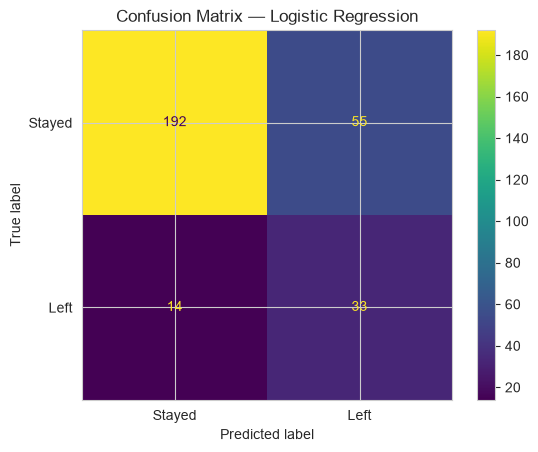

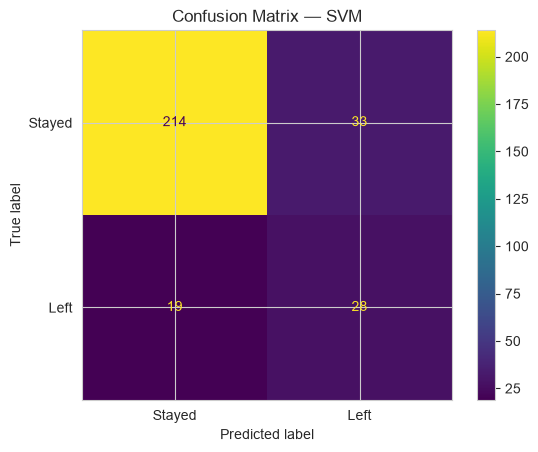

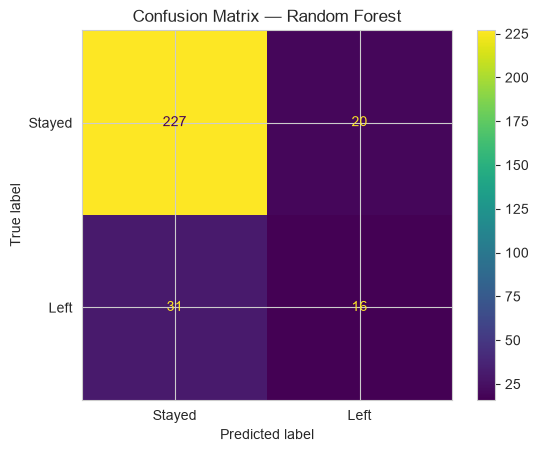

In [64]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

for name, model in tuned_models.items():

    y_pred = model.predict(X_test)

    ConfusionMatrixDisplay.from_predictions(
        y_test,
        y_pred,
        display_labels=["Stayed", "Left"]
    )

    plt.title(f"Confusion Matrix — {name}")
    plt.show()

## 7.16 Model Comparison

The performance of the three supervised learning models is compared using the evaluation metrics calculated on the held-out test set.

Accuracy is included for completeness, but it is not used as the sole criterion for selecting the final model because of the class imbalance.

Greater emphasis is placed on F1-score and PR-AUC, while precision and recall are also considered in relation to the HR flight-risk objective.

The comparison allows us to identify which model provides the most useful balance between correctly identifying employees who are likely to leave and avoiding excessive false alarms.


In [65]:
# Display the comparison table
evaluation_df.sort_values(
    by="F1",
    ascending=False
).round(3)

,Model,Accuracy,Precision,Recall,F1,PR-AUC
1,SVM,0.823,0.459,0.596,0.519,0.569
0,Logistic Regression,0.765,0.375,0.702,0.489,0.624
2,Random Forest,0.827,0.444,0.340,0.386,0.431


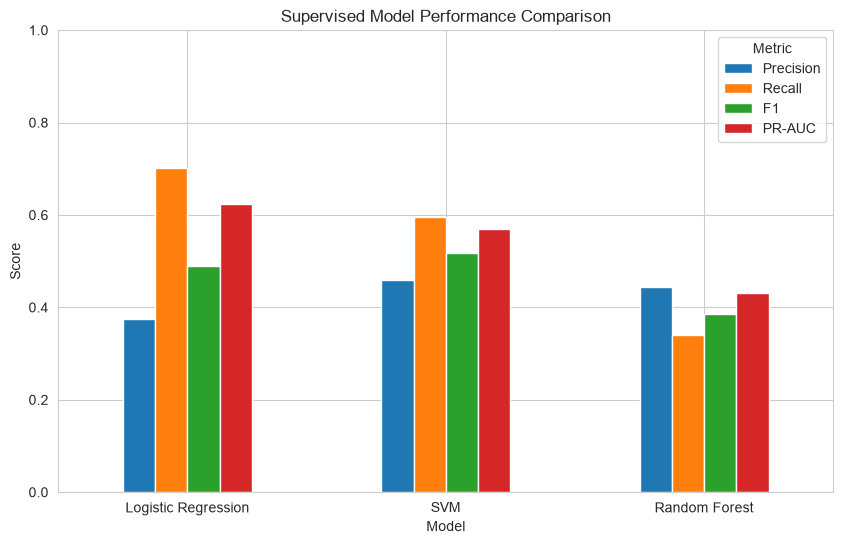

In [66]:
# Creating Visual Comparisons
metrics_to_plot = [
    "Precision",
    "Recall",
    "F1",
    "PR-AUC"
]

evaluation_df.set_index("Model")[metrics_to_plot].plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Supervised Model Performance Comparison")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend(title="Metric")
plt.show()

### 7.17 Final Model Selection

The final model is selected primarily based on its test-set F1-score because the attrition class is the minority class.

F1-score provides a balance between precision and recall, which is important for the HR flight-risk objective. PR-AUC, precision, and recall are also considered when interpreting the model's suitability for identifying employees who may be at risk of leaving.

The model with the highest test-set F1-score is selected as the final model for model interpretation.

The selected model should therefore be understood as the model that provides the most suitable predictive performance for the project's specific objective, rather than simply the model with the highest accuracy.

SVM was selected because it achieved the highest test-set F1-score (0.519), providing the best balance between precision and recall among the three tuned models. Logistic Regression achieved a higher PR-AUC (0.624), but its F1-score was slightly lower (0.489).

In [67]:
# Select the model with the highest test-set F1-score
best_model_name = evaluation_df.loc[
    evaluation_df["F1"].idxmax(),
    "Model"
]

# Retrieve the selected fitted pipeline
final_model = tuned_models[best_model_name]

print("Selected final model:", best_model_name)

print("\nPerformance:")
print(
    evaluation_df[
        evaluation_df["Model"] == best_model_name
    ].round(3)
)

Selected final model: SVM

Performance:
  Model  Accuracy  Precision  Recall     F1  PR-AUC
1   SVM     0.823      0.459   0.596  0.519   0.569


In [68]:
import joblib
import os

# Create models folder if it does not exist
os.makedirs("models", exist_ok=True)

# Save the complete preprocessing + SVM pipeline
joblib.dump(
    final_model,
    "models/final_model.pkl"
)

print("Final model saved successfully!")
print("Model:", best_model_name)
print("Location: models/final_model.pkl")

Final model saved successfully!
Model: SVM
Location: models/final_model.pkl


In [73]:
df["Risk Probability"] = model.predict_proba(
    df.drop(columns=["Attrition"])
)[:, 1]

# 8. Model Interpretation

Predictive performance alone is not sufficient for an HR flight-risk application. HR decision-makers also need to understand which employee characteristics contribute to predictions.

Model interpretation is therefore used to identify the factors associated with the model's predictions.

This section examines feature importance and, where appropriate, SHAP explanations. The objective is not to claim that the identified features cause attrition. Instead, the features are interpreted as variables that contribute to the model's predictive decisions.

This distinction is important because the dataset is observational and predictive relationships should not automatically be interpreted as causal relationships.


## 8.1 Model Interpretation Overview

Model interpretation is used to explain how the final SVM arrives at its attrition predictions. This section first examines global feature importance and then explains the prediction for one individual employee using SHAP.

## 8.2 Model Interpretation Approach

Because the selected final model is an SVM, built-in tree feature importance is not available. SHAP (SHapley Additive exPlanations) is therefore used to explain how each feature contributes to the model predictions.

The analysis has two levels:
- **Global interpretation:** identify the features that contribute most strongly to the model across employees.
- **Individual interpretation:** explain why the model predicted a particular employee as higher or lower flight risk.

Only the features actually used by the current preprocessing pipeline are included in the SHAP analysis.

In [69]:
# Prepare the data in the exact feature space used by the fitted SVM
# This includes both numerical variables and one-hot encoded categorical variables.

final_model = tuned_models[best_model_name]

# Access the fitted preprocessing and classifier steps
fitted_preprocessor = final_model.named_steps["preprocessor"]
svm_classifier = final_model.named_steps["classifier"]

# Transform training and test data using the already-fitted preprocessing pipeline
X_train_transformed = fitted_preprocessor.transform(X_train)
X_test_transformed = fitted_preprocessor.transform(X_test)

# SHAP KernelExplainer works more reliably with dense numeric arrays
if hasattr(X_train_transformed, "toarray"):
    X_train_transformed = X_train_transformed.toarray()
    X_test_transformed = X_test_transformed.toarray()

# Names of the actual features supplied to the SVM after preprocessing
transformed_feature_names = fitted_preprocessor.get_feature_names_out()

print("Selected final model:", best_model_name)
print("Original features:", X_train.shape[1])
print("Features after preprocessing:", len(transformed_feature_names))

Selected final model: SVM
Original features: 30
Features after preprocessing: 50


In [76]:
pip install shap

  Using cached shap-0.52.0-cp312-abi3-win_amd64.whl.metadata (26 kB)
  Using cached tqdm-4.70.1-py3-none-any.whl.metadata (57 kB)
  Using cached slicer-0.0.8-py3-none-any.whl.metadata (4.0 kB)
  Using cached numba-0.67.0-cp312-cp312-win_amd64.whl.metadata (2.8 kB)
  Using cached llvmlite-0.49.0-cp312-cp312-win_amd64.whl.metadata (5.2 kB)
Using cached shap-0.52.0-cp312-abi3-win_amd64.whl (499 kB)
Using cached slicer-0.0.8-py3-none-any.whl (15 kB)
Using cached tqdm-4.70.1-py3-none-any.whl (80 kB)
   ---------------------------------------- 0.0/41.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/41.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/41.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/41.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/41.9 MB ? eta -:--:--
   ---------------------------------------- 0.3/41.9 MB ? eta -:--:--
    --------------------------------------- 0.5/41.9 MB 1.0 MB/s eta 0:00:40
   

### 8.3 SHAP Explainer

The course XGBoost notebook demonstrates SHAP using `TreeExplainer`, while the Random Forest notebook demonstrates built-in and permutation feature importance. Our selected final model for Group 8 is an **SVM**, so a tree-specific explainer cannot be used for the final model.

We therefore use **SHAP KernelExplainer**, a model-agnostic method. The explainer operates on the complete preprocessed feature matrix, including the one-hot encoded categorical variables. This ensures that the explanation corresponds to the actual features used by the SVM.

In [77]:

import shap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Create a small representative background sample
background_size = min(30, len(X_train_transformed))

background = shap.sample(
    X_train_transformed,
    background_size,
    random_state=42
)

print("Background sample shape:", background.shape)

# Function that returns the SVM probability for each class
def svm_probability(X):
    return svm_classifier.predict_proba(X)

# Create the SHAP KernelExplainer
explainer = shap.KernelExplainer(
    svm_probability,
    background
)

print("SHAP KernelExplainer created successfully.")
print(
    "Expected probability for Stayed (0): "
    f"{explainer.expected_value[0]:.3f}"
)
print(
    "Expected probability for Left (1): "
    f"{explainer.expected_value[1]:.3f}"
)

Background sample shape: (30, 50)
SHAP KernelExplainer created successfully.
Expected probability for Stayed (0): 0.832
Expected probability for Left (1): 0.168


### 8.4 Global SHAP Feature Importance

The course XGBoost notebook uses a SHAP summary plot to show which features have the strongest influence on predictions. We follow the same interpretation here, but because our SVM uses one-hot encoding, several encoded columns can belong to the same original employee feature.

For HR readability, SHAP contributions are therefore aggregated back to the **original employee variables** such as `JobRole`, `OverTime`, `MonthlyIncome`, and `JobSatisfaction`.

In [78]:
# Calculate SHAP values for a sample of test employees
shap_sample_size = min(100, len(X_test_transformed))

X_test_shap = shap.sample(
    X_test_transformed,
    shap_sample_size,
    random_state=42
)

print("SHAP sample shape:", X_test_shap.shape)

SHAP sample shape: (100, 50)


In [79]:
# Calculate SHAP values for the selected test sample

shap_values = explainer.shap_values(
    X_test_shap,
    nsamples=200
)

print("SHAP values calculated successfully.")

  0%|          | 0/100 [00:00<?, ?it/s]

SHAP values calculated successfully.


In [80]:
# Check the SHAP output structure
print("SHAP values type:", type(shap_values))
print("SHAP values shape:", np.asarray(shap_values).shape)

SHAP values type: <class 'numpy.ndarray'>
SHAP values shape: (100, 50, 2)


In [81]:
# Use SHAP values for class 1: employee leaves
shap_values_left = shap_values[:, :, 1]

# Calculate the mean absolute SHAP value for each feature
mean_abs_shap = np.abs(shap_values_left).mean(axis=0)

# Create the global SHAP importance table
global_shap_importance = pd.DataFrame({
    "Feature": transformed_feature_names,
    "Mean |SHAP Value|": mean_abs_shap
})

# Sort from most important to least important
global_shap_importance = (
    global_shap_importance
    .sort_values(
        "Mean |SHAP Value|",
        ascending=False
    )
    .reset_index(drop=True)
)

print("Top 15 model features influencing attrition predictions:")

display(
    global_shap_importance
    .head(15)
    .round(4)
)

Top 15 model features influencing attrition predictions:


,Feature,Mean |SHAP Value|
0,num__OverTime,0.0552
1,num__Age,0.0183
2,num__EnvironmentSatisfaction,0.0176
3,num__StockOptionLevel,0.0174
4,num__NumCompaniesWorked,0.0173
5,num__DistanceFromHome,0.0154
6,num__TotalWorkingYears,0.0149
7,num__RelationshipSatisfaction,0.0124
8,num__JobInvolvement,0.0089
9,num__JobSatisfaction,0.0084


### Interpretation of Global SHAP Results

The SHAP analysis shows that **OverTime** had the strongest influence on the SVM's attrition predictions, followed by StockOptionLevel, Age, EnvironmentSatisfaction, and other employee-related factors.

These results describe the contribution of each feature to the model's predictions and should not be interpreted as evidence of causation.

For example, we should not conclude that "OverTime causes employees to leave." Instead, we can state that **OverTime had the strongest influence on the SVM's attrition predictions in our SHAP analysis.**

SHAP explains model prediction contribution, not causation.

In [82]:
# Map each transformed feature back to its original employee feature

original_feature_for_transformed = []

for name in transformed_feature_names:

    if name.startswith("num__"):

        original_feature_for_transformed.append(
            name.replace("num__", "", 1)
        )

    elif name.startswith("cat__"):

        encoded_name = name.replace("cat__", "", 1)

        matched = None

        for col in categorical_features:

            if encoded_name == col or encoded_name.startswith(col + "_"):
                matched = col
                break

        original_feature_for_transformed.append(
            matched if matched is not None else encoded_name
        )

    else:

        original_feature_for_transformed.append(name)


# Aggregate SHAP values back to original employee features

global_importance = pd.DataFrame({
    "Original Feature": original_feature_for_transformed,
    "Mean |SHAP|": np.abs(shap_values_left).mean(axis=0)
})

global_importance = (
    global_importance
    .groupby(
        "Original Feature",
        as_index=False
    )["Mean |SHAP|"]
    .sum()
    .sort_values(
        "Mean |SHAP|",
        ascending=False
    )
    .reset_index(drop=True)
)

print("Global SHAP Feature Importance")

display(
    global_importance
    .head(15)
    .round(4)
)

Global SHAP Feature Importance


,Original Feature,Mean |SHAP|
0,OverTime,0.0552
1,Age,0.0183
2,EnvironmentSatisfaction,0.0176
3,StockOptionLevel,0.0174
4,NumCompaniesWorked,0.0173
5,DistanceFromHome,0.0154
6,TotalWorkingYears,0.0149
7,RelationshipSatisfaction,0.0124
8,JobRole,0.0121
9,JobInvolvement,0.0089


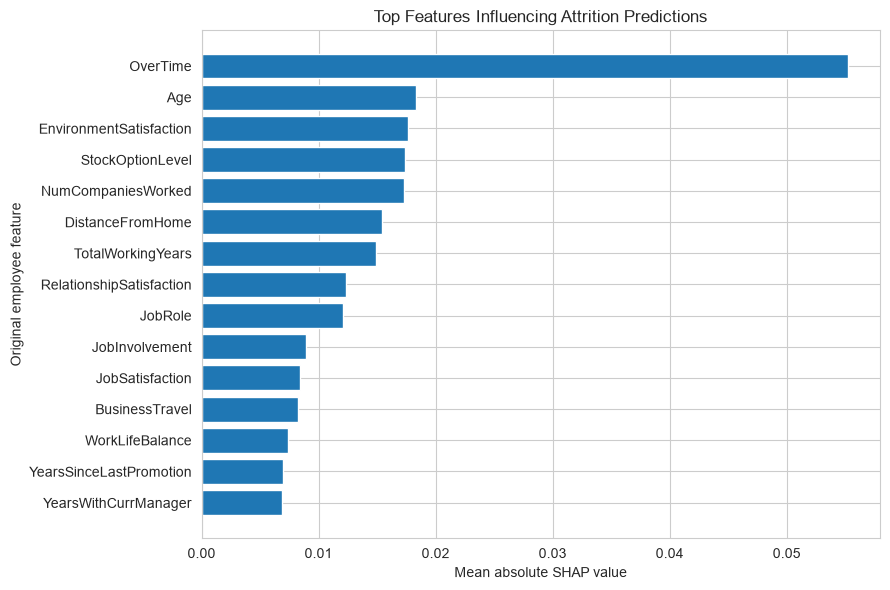

In [83]:
# Plot the top 15 original employee features
top_features = global_importance.head(15).sort_values("Mean |SHAP|")

plt.figure(figsize=(9, 6))
plt.barh(
    top_features["Original Feature"],
    top_features["Mean |SHAP|"]
)
plt.xlabel("Mean absolute SHAP value")
plt.ylabel("Original employee feature")
plt.title("Top Features Influencing Attrition Predictions")
plt.tight_layout()
plt.show()


### 8.5 Individual-Employee Explanation

To satisfy the Group 8 requirement, we explain one **specific unseen employee** from the held-out test set.

We select the employee with the highest predicted probability of attrition. A **positive SHAP contribution** pushes the prediction toward `Attrition = 1 (Left)`, while a **negative contribution** pushes it toward `Attrition = 0 (Stayed)`.

For categorical variables, the SHAP values of their one-hot encoded columns are combined so that HR can see the contribution of the original variable rather than a technical dummy-column name.

In [84]:
# Find the highest-risk employee in the held-out test set
test_probabilities = final_model.predict_proba(X_test)[:, 1]
highest_risk_position = int(np.argmax(test_probabilities))
highest_risk_index = X_test.index[highest_risk_position]

employee_raw = X_test.loc[[highest_risk_index]]
employee_transformed = X_test_transformed[highest_risk_position:highest_risk_position + 1]

employee_probability = test_probabilities[highest_risk_position]
employee_prediction = int(final_model.predict(employee_raw)[0])
employee_actual = int(y_test.loc[highest_risk_index])

print("Individual Employee Explanation")
print("--------------------------------")
print("Employee index:", highest_risk_index)
print("Actual attrition:", "Left" if employee_actual == 1 else "Stayed")
print("Predicted attrition:", "Left" if employee_prediction == 1 else "Stayed")
print(f"Predicted probability of leaving: {employee_probability:.3f}")

# Show the employee's original profile
display(employee_raw.T.rename(columns={highest_risk_index: "Employee Value"}))


Individual Employee Explanation
--------------------------------
Employee index: 357
Actual attrition: Left
Predicted attrition: Left
Predicted probability of leaving: 0.931


,Employee Value
Age,21
BusinessTravel,Travel_Frequently
DailyRate,756
Department,Sales
DistanceFromHome,1
Education,1
EducationField,Technical Degree
EnvironmentSatisfaction,1
Gender,Female
HourlyRate,99


In [86]:
# Calculate SHAP values for this individual employee
individual_shap_raw = explainer.shap_values(
    employee_transformed,
    nsamples=200
)

if isinstance(individual_shap_raw, list):
    individual_shap_left = np.asarray(individual_shap_raw[1])[0]
else:
    individual_array = np.asarray(individual_shap_raw)
    if individual_array.ndim == 3:
        if individual_array.shape[2] == 2:
            individual_shap_left = individual_array[0, :, 1]
        elif individual_array.shape[0] == 2:
            individual_shap_left = individual_array[1, 0]
        else:
            raise ValueError(f"Unexpected individual SHAP shape: {individual_array.shape}")
    else:
        individual_shap_left = individual_array[0]

# Aggregate encoded SHAP values back to the original employee variables
individual_explanation = pd.DataFrame({
    "Feature": original_feature_for_transformed,
    "SHAP Value": individual_shap_left
}).groupby(
    "Feature",
    as_index=False
)["SHAP Value"].sum()

# Add the employee's original value for each feature
employee_values = employee_raw.iloc[0].to_dict()
individual_explanation["Employee Value"] = individual_explanation["Feature"].map(employee_values)

individual_explanation["Direction"] = np.where(
    individual_explanation["SHAP Value"] > 0,
    "Increases flight-risk prediction",
    "Decreases flight-risk prediction"
)

individual_explanation["Absolute SHAP"] = np.abs(
    individual_explanation["SHAP Value"]
)

print("Top factors influencing this employee's prediction:")
display(
    individual_explanation
    .sort_values("Absolute SHAP", ascending=False)
    .head(10)
    [["Feature", "Employee Value", "SHAP Value", "Direction"]]
    .round(4)
)


  0%|          | 0/1 [00:00<?, ?it/s]

Top factors influencing this employee's prediction:


,Feature,Employee Value,SHAP Value,Direction
18,OverTime,1,0.1603,Increases flight-risk prediction
15,MonthlyIncome,2174,0.1012,Increases flight-risk prediction
7,EnvironmentSatisfaction,1,0.0991,Increases flight-risk prediction
0,Age,21,0.0925,Increases flight-risk prediction
12,JobRole,Sales Representative,0.0657,Increases flight-risk prediction
23,TotalWorkingYears,3,0.0644,Increases flight-risk prediction
1,BusinessTravel,Travel_Frequently,0.0633,Increases flight-risk prediction
19,PercentSalaryHike,11,0.0506,Increases flight-risk prediction
14,MaritalStatus,Single,0.0487,Increases flight-risk prediction
24,TrainingTimesLastYear,3,0.0165,Increases flight-risk prediction


### 8.6 Individual SHAP Waterfall Plot

The waterfall plot gives a visual explanation of the selected employee's prediction. Features with positive contributions push the prediction toward higher attrition risk, while negative contributions push it toward lower risk.

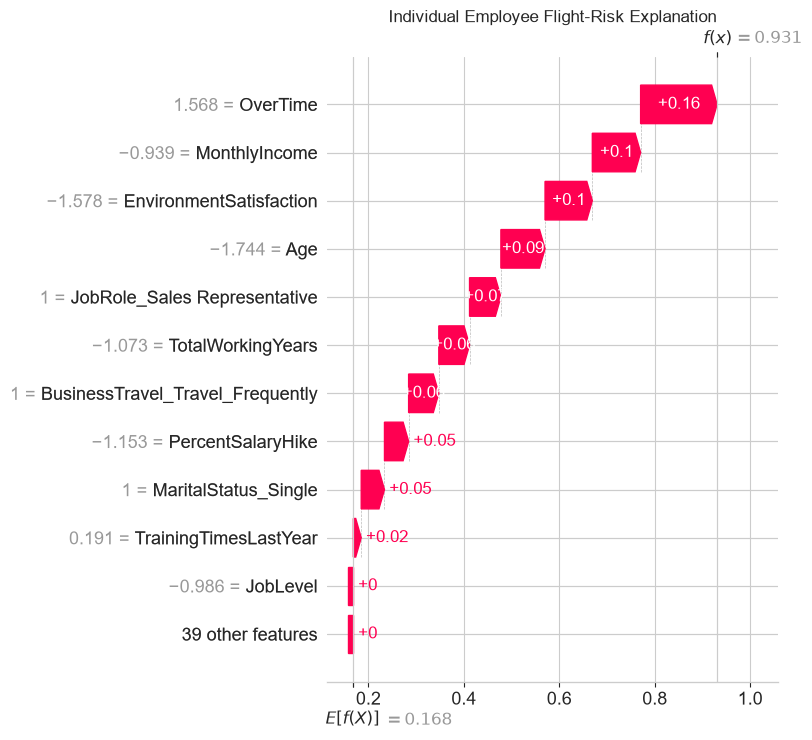

In [87]:
# Create a SHAP waterfall explanation in the preprocessed feature space

# Get SHAP values for class 1 (Attrition = Left)
individual_shap_left = np.asarray(individual_shap_left).flatten()

# Clean the transformed feature names by removing preprocessing prefixes
clean_feature_names = [
    name.replace("num__", "")
        .replace("cat__", "")
    for name in transformed_feature_names
]

# Get the expected value for class 1 (Attrition = Left)
if isinstance(explainer.expected_value, (list, np.ndarray)):
    base_value = explainer.expected_value[1]
else:
    base_value = explainer.expected_value

# Create the SHAP Explanation object
individual_explanation_object = shap.Explanation(
    values=individual_shap_left,
    base_values=base_value,
    data=employee_transformed[0],
    feature_names=clean_feature_names
)

# Display the SHAP waterfall plot
plt.figure(figsize=(10, 7))

shap.plots.waterfall(
    individual_explanation_object,
    max_display=12,
    show=False
)

plt.title("Individual Employee Flight-Risk Explanation")
plt.tight_layout()
plt.show()

### 8.7 Interpretation for HR

The SHAP analysis provides two levels of interpretation:

1. **Global interpretation:** the largest mean absolute SHAP values identify the employee characteristics that the SVM relies on most strongly when making attrition predictions.
2. **Individual interpretation:** for the selected employee, positive SHAP contributions push the prediction toward higher flight risk and negative contributions push it toward lower flight risk.

### Individual Employee Example

For the selected Employee 357, the SVM predicted a 93.1% probability of leaving, and the employee's actual outcome was also Left.

The strongest factors increasing this employee's predicted flight risk were Age, OverTime, BusinessTravel, TotalWorkingYears, EnvironmentSatisfaction, JobLevel and JobInvolvement. In particular, Age and OverTime had the largest positive SHAP contributions for this employee.

These results explain the model's prediction for this individual; they do not establish that these characteristics caused the employee to leave.

### HR Implication

The model can be used as an early-warning and decision-support tool to help HR identify patterns associated with potential attrition. It should not be used to automatically label employees as flight risks or to make employment decisions. Any intervention should consider the employee's broader context and should not rely on the model prediction alone.

## 9. Overall Conclusion

The analysis combined exploratory data analysis, employee segmentation and supervised learning to investigate employee attrition risk.

The unsupervised analysis identified two employee personas with different levels of observed attrition. The supervised analysis compared Logistic Regression, SVM and Random Forest models while accounting for class imbalance. SVM achieved the highest test-set F1-score of 0.519 and was therefore selected as the final model.

SHAP analysis showed that OverTime had the strongest overall influence on the SVM's attrition predictions. At the individual level, Employee 357 was predicted to have a 93.1% probability of leaving, and the employee's actual outcome was also Left.

The results demonstrate that machine learning can provide useful early-warning information for employee attrition. However, the predictions represent model-based associations rather than causal explanations and should therefore support, rather than replace, human judgement in HR decision-making.